# BlackJAX Nested Sampling + MLGW BBH

Analogue of the SHARPy notebook but using [BlackJAX Nested Sampling](https://github.com/handley-lab/blackjax/tree/nested_sampling) (Handley-lab fork) as the sampler instead of SHARPy SMC.

## PREVIOUS REQUIREMENTS

In [ ]:
!nvidia-smi

Fri May 22 09:18:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             57W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# ---------------------------------------------------------------
# Environment setup — runs the full pip install only on Colab.
# Locally, activate the mlgw_bns conda environment instead.
# ---------------------------------------------------------------
import sys, subprocess, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print('Running in Google Colab — installing all dependencies...')
    # MLGW from source (new_training branch)
    if not os.path.exists('MLGW'):
        subprocess.check_call(['git', 'clone', '-b', 'new_training', '--single-branch',
                               'https://github.com/adrianomascioli/MLGW.git'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', 'MLGW/'])
    # Core dependencies
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'lalsuite', 'precession', 'keras-tuner', 'tf2jax',
                           'corner', 'anesthetic'])
    # BlackJAX nested sampling (Handley-lab fork)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'git+https://github.com/handley-lab/blackjax.git@nested_sampling'])
    # SHARPy GW likelihood
    if not os.path.exists('sharpy'):
        subprocess.check_call(['git', 'clone', '-b', 'saulo-lorenzo-adriano-patch-beta',
                               '--single-branch',
                               'https://github.com/saulo-albuquerque-phys/sharpy.git'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-e', 'sharpy/'])
    # Fix ripplegw import path (ms_to_Mc_eta moved to ripplegw.conversions in v0.1.1)
    subprocess.check_call(['sed', '-i',
                           's/from ripplegw import ms_to_Mc_eta/from ripplegw.conversions import ms_to_Mc_eta/',
                           'sharpy/sharpy/GW_likelihood.py'])
    print('Colab setup complete.')
else:
    print('Running locally — mlgw_bns conda environment expected.')


Running in Google Colab — installing all dependencies...


KeyboardInterrupt: 

In [ ]:
# ── Google Colab environment setup ──────────────────────────────────────
# Run this cell first on Colab; it is a no-op on local machines.
import os, subprocess, sys

COLAB    = "google.colab" in sys.modules
REPO_DIR = "/content/mlgw_bns_jax" if COLAB else os.getcwd()

if COLAB:
    # ── Other Python dependencies ──────────────────────────────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "gwpy", "h5py", "corner", "tqdm", "anesthetic",
    ])
    # ── BlackJAX (nested_sampling branch, pinned commit) ──────────────
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "blackjax@git+https://github.com/handley-lab/blackjax.git"
        "@dedbf11da33eb5ca286f6731e2c51f2b254b953f",
    ])


    # ── Clone blackjax_ns_gw (custom NS kernels) ──────────────────────
    _ns_repo   = os.path.join(REPO_DIR, "_blackjax_ns_gw_repo")
    _ns_src    = os.path.join(_ns_repo,  "src", "custom_kernels")
    _ns_link   = os.path.join(REPO_DIR,  "custom_kernels")
    if not os.path.isdir(_ns_repo):
        subprocess.check_call([
            "git", "clone", "--depth", "1",
            "https://github.com/mrosep/blackjax_ns_gw.git",
            _ns_repo,
        ])
    if not os.path.exists(_ns_link):
        os.symlink(_ns_src, _ns_link)

In [ ]:
# GPU-enabled JAX (Colab GPU / local CUDA runtime) — skip on CPU-only.
!pip install --upgrade "jax[cuda12]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

In [ ]:
!pip install keras-tuner

In [ ]:
!pip install tf2jax

In [ ]:
# Install BlackJAX from the Handley-lab nested sampling branch
!pip install git+https://github.com/handley-lab/blackjax.git@nested_sampling

In [ ]:
!pip install corner anesthetic

## SETTING UP MLGW

In [ ]:
!sed -i 's/lambda: jnp.array(0.0)/lambda: jnp.array(0.0, dtype=term.dtype)/g' /content/MLGW/mlgw/GW_generator.py

In [ ]:
!python --version

Python 3.11.13


In [ ]:
import sys
import os

# Add the cloned MLGW directory to the Python path if not already there
mlgw_path = os.path.abspath('MLGW')
if mlgw_path not in sys.path:
    sys.path.insert(0, mlgw_path)

# Add the cloned sharpy directory to the Python path if not already there
sharpy_path = os.path.abspath('sharpy')
if sharpy_path not in sys.path:
    sys.path.insert(0, sharpy_path)

import mlgw
from mlgw.GW_generator import GW_generator
from mlgw.GW_FD_generator import GW_FD_generator

In [ ]:
gwgen = GW_generator()

/content/MLGW/mlgw/TD_models/model_4/21/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/33/amp_weights_0123.keras
['1-mc

/content/MLGW/mlgw/GW_generator.py:170: UserWarning: Folder .DS_Store: name not recognized as a valid mode - skipping its content
  warnings.warn('Folder {}: name not recognized as a valid mode - skipping its content'.format(name))


/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/ph_weights_01_residual.keras


In [ ]:
import jax
import jax.numpy as jnp

In [ ]:
time_array = jnp.linspace(-5, 0.1, 10000)

In [ ]:
theta_7 = jnp.array([10, 15, 0.5, -0.3, 1, 0, 0])

In [ ]:
h__p, h__c = gwgen.get_WF(theta_7, time_array, modes=[(2,2)])


In [ ]:
h__p.shape

(10000,)

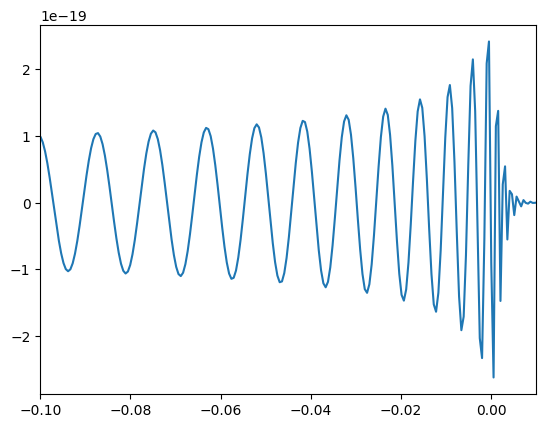

In [ ]:
import matplotlib.pyplot as plt
plt.plot(time_array, h__p)
plt.xlim(-0.1, 0.01)
plt.show()

In [ ]:
gw_fd_generator = GW_FD_generator(
    duration=4.,
    sampling_frequency=2048,
    final_time=0.1,
    modes=[(2,2)],
    alpha_left=0.1,
    alpha_right=0.001
)

/content/MLGW/mlgw/TD_models/model_4/21/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/33/amp_weights_0123.keras
['1-mc

/content/MLGW/mlgw/GW_generator.py:170: UserWarning: Folder .DS_Store: name not recognized as a valid mode - skipping its content
  warnings.warn('Folder {}: name not recognized as a valid mode - skipping its content'.format(name))


/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/22/ph_weights_01.keras
['3-mc_et

In [ ]:
gw_fd_generator = GW_FD_generator(
    duration=4.,
    sampling_frequency=2048,
    final_time=0.1,
    modes=[(2,2)],
    alpha_left=0.1,
    alpha_right=0.001
)

/content/MLGW/mlgw/TD_models/model_4/21/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/33/amp_weights_0123.keras
['1-mc

/content/MLGW/mlgw/GW_generator.py:170: UserWarning: Folder .DS_Store: name not recognized as a valid mode - skipping its content
  warnings.warn('Folder {}: name not recognized as a valid mode - skipping its content'.format(name))


/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/22/ph_weights_01.keras
['3-mc_et

In [ ]:
#gw_fd_generator = GW_FD_generator(
#    duration=2.,
#    sampling_frequency=2048,
#    final_time=0.1,
#    modes=[(2,2),(2,1),(3,2),(3,3),(4,3),(4,4),(5,5)],
#    alpha_left=0.1,
#    alpha_right=0.001
#)


In [ ]:
def waveform_mlgw_fd(theta):
    wf = gw_fd_generator.frequency_domain_strain()
    return wf["plus"], wf["cross"]

## SETTING UP GW NETWORK

In [ ]:
import numpy as np

In [ ]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

In [ ]:
from sharpy.GW_likelihood import waveform_mlgw
hp, hc = waveform_mlgw(jnp.array([24, 10, 0.5, 0.3, 1, 0, 0]))

/usr/local/lib/python3.11/dist-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


/content/MLGW/mlgw/TD_models/model_4/21/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/21/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/33/amp_weights_0123.keras
['1-mc

/content/MLGW/mlgw/GW_generator.py:170: UserWarning: Folder .DS_Store: name not recognized as a valid mode - skipping its content
  warnings.warn('Folder {}: name not recognized as a valid mode - skipping its content'.format(name))


/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_01.keras
['3-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3), (0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 0, 3), (0, 1, 1), (0, 1, 2), (0, 1, 3), (0, 2, 2), (0, 2, 3), (0, 3, 3), (1, 1, 1), (1, 1, 2), (1, 1, 3), (1, 2, 2), (1, 2, 3), (1, 3, 3), (2, 2, 2), (2, 2, 3), (2, 3, 3), (3, 3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/32/ph_weights_2345.keras
['1-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/amp_weights_0123.keras
['1-mc_chieff']
 
 features_spec:  {'base': [0, 3], 'poly': []}
/content/MLGW/mlgw/TD_models/model_4/22/ph_weights_01_residual.keras
['2-mc_eta_logq_chieff']
 
 features_spec:  {'base': [0, 1, 2, 3], 'poly': [(0, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]}
/content/MLGW/mlgw/TD_models/model_4/22/ph_weights_01.keras
['3-mc_et

In [ ]:
detector_settings = {
    "H1": {
        "psd_file"    : None,
        "channel"     : 'GWOSC',
        "download_data": True,
        "duration"    : 2.0,
    },
    "L1": {
        "psd_file"    : None,
        "channel"     : 'GWOSC',
        "download_data": True,
        "duration"    : 2.0,
    },
}

In [ ]:
from sharpy.GW_likelihood import GWNetwork, log_likelihood_det_mlgw

In [ ]:
gw_network = GWNetwork(detector_settings)


Using GWPY to download data.

Loaded channel GWOSC starting at 1126259446.0 length 32.0s.
Estimating power spectral density with the Welch method

Using GWPY to download data.

Loaded channel GWOSC starting at 1126259446.0 length 32.0s.
Estimating power spectral density with the Welch method


In [ ]:
from functools import partial
batched_detector = gw_network.batched_detector

In [ ]:
log_likelihood = partial(log_likelihood_det_mlgw, detector_list=batched_detector)
log_likelihood_jit=jax.jit(log_likelihood)

## BLACKJAX NESTED SAMPLING CONFIGURATION

Parameters: `['ra', 'dec', 'logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2']`

The nested sampler requires a **prior transform** mapping the unit hypercube $[0,1]^D \to$ parameter space, and the same `log_likelihood` used by SHARPy.

In [ ]:
parameters_names = ['ra', 'dec', 'logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2']
n_params = len(parameters_names)

# Uniform prior bounds  [lower, upper] for each parameter
# Same bounds as used in the SHARPy notebook
prior_bounds = jnp.array([
    [0,          2*jnp.pi ],   # ra
    [-jnp.pi/2,  jnp.pi/2 ],   # dec
    [4.3,        6.4      ],   # logdistance
    [0,          jnp.pi   ],   # theta_jn
    [0.,         2*jnp.pi ],   # phiref
    [0,          jnp.pi   ],   # pol
    [25,         35       ],   # mc
    [0.4,        1.       ],   # q
    [0.0,        0.2      ],   # tc
    [-1.,        1.       ],   # chi1
    [-1.,        1.       ],   # chi2
])

print("Parameters:", parameters_names)
print("Prior bounds shape:", prior_bounds.shape)

Parameters: ['ra', 'dec', 'logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2']
Prior bounds shape: (11, 2)


In [ ]:
def prior_transform(u):
    """Map unit-hypercube sample u ∈ [0,1]^D to parameter space."""
    theta = prior_bounds[:, 0] + u * (prior_bounds[:, 1] - prior_bounds[:, 0])

    # Volumetric distance prior (p(d) ~ d^2 => P(d) ~ d^3)
    d_min = jnp.exp(prior_bounds[2, 0])
    d_max = jnp.exp(prior_bounds[2, 1])
    d = (d_min**3 + u[2] * (d_max**3 - d_min**3)) ** (1./3.)
    theta = theta.at[2].set(jnp.log(d))

    # Sine prior on theta_jn (uniform in cos(theta_jn))
    cos_min = jnp.cos(prior_bounds[3, 0])
    cos_max = jnp.cos(prior_bounds[3, 1])
    cos_theta = cos_min + u[3] * (cos_max - cos_min)
    theta = theta.at[3].set(jnp.arccos(cos_theta))

    return theta

def logprior_fn(theta):
    """Log-prior with volumetric distance and sine inclination priors."""
    in_bounds = jnp.all((theta >= prior_bounds[:, 0]) & (theta <= prior_bounds[:, 1]))

    # p(log_d) ~ d^3 -> log(p) = 3 * log_d
    # p(theta_jn) ~ sin(theta_jn) -> log(p) = log(sin(theta_jn))
    log_p = 3.0 * theta[2] + jnp.log(jnp.sin(theta[3]))

    return jnp.where(in_bounds, log_p, -jnp.inf)


In [ ]:
import blackjax
import blackjax.ns as bns
print("BlackJAX version:", blackjax.__version__)


BlackJAX version: 0.1.0b1.dev194+g2180e29ff


## RUNNING BLACKJAX NESTED SAMPLING

In [ ]:
import os
import time

# ---- Sampler configuration (analogous to SHARPy hyperparams) ----
n_live        = 5000       # number of live points (analogous to number_of_particles)
n_delete      = 4000         # points removed per NS iteration
num_mcmc_steps = 500        # MCMC slice steps per replacement
rng_seed      = 43        # same seed as SHARPy runs
run_id        = 3

folder = f"test_GW150914_bns/run_{run_id}"
label  = f"run_{run_id}"
os.makedirs(folder, exist_ok=True)

print(f"n_live={n_live}, folder={folder}")

n_live=5000, folder=test_GW150914_bns/run_3


In [ ]:
rng_key = jax.random.PRNGKey(rng_seed)
rng_key, init_key = jax.random.split(rng_key)

# Sample initial live points from the prior via the prior transform
u0 = jax.random.uniform(init_key, shape=(n_live, n_params))
live_points = jax.vmap(prior_transform)(u0)

print('live_points shape:', live_points.shape)


live_points shape: (5000, 11)


In [ ]:
# Build the Nested Slice Sampler
# bns.nss.as_top_level_api is the correct entry-point (bns.nss is a module, not callable)
ns_algorithm = bns.nss.as_top_level_api(
    logprior_fn=logprior_fn,
    loglikelihood_fn=log_likelihood,
    num_inner_steps=num_mcmc_steps,
    num_delete=n_delete,
)

# Initialise state — log-likelihoods evaluated internally
state = ns_algorithm.init(live_points)
print('Initial logZ:     ', float(state.integrator.logZ))
print('Initial logZ_live:', float(state.integrator.logZ_live))


Initial logZ:      -inf
Initial logZ_live: -1580.1020157209134


In [ ]:
# ---- Main nested sampling loop ----
convergence_dlogZ = 0.5  # stop when live Z / total Z < 1%
max_iterations    = 10_000

dead_points  = []
log_Ls_dead  = []

time0 = time.time()

for i in range(max_iterations):
    rng_key, step_key = jax.random.split(rng_key)
    state, info = ns_algorithm.step(step_key, state)

    # info.particles is a StateWithLogLikelihood; shape (n_delete, n_params)
    for pos, ll in zip(info.particles.position, info.particles.loglikelihood):
        dead_points.append(np.array(pos))
        log_Ls_dead.append(float(ll))

    # Convergence: live contribution < fraction of accumulated evidence
    logZ_acc  = float(state.integrator.logZ)
    logZ_live = float(state.integrator.logZ_live)
    if logZ_live < logZ_acc + np.log(convergence_dlogZ):
        print(f'Converged at iteration {i+1}')
        break

timef = time.time()
result_time = timef - time0
print(f'Nested sampling finished in {result_time/60:.2f} min  ({i+1} iterations)')


In [ ]:
# ---- Extract evidence and posterior samples ----
logZ        = float(state.integrator.logZ)
dead_points = np.array(dead_points)   # shape (n_dead, n_params)
log_Ls_dead = np.array(log_Ls_dead)   # shape (n_dead,)

# Reconstruct log weights: X_i ≈ exp(-i/n_live), ΔX_i ≈ X_i*(1 - exp(-1/n_live))
n_dead       = len(dead_points)
i_arr        = np.arange(1, n_dead + 1)
log_X_i      = -i_arr / n_live
log_delta_X  = log_X_i + np.log1p(-np.exp(-1.0 / n_live))
log_weights  = log_Ls_dead + log_delta_X

# Importance resampling
log_weights_norm = log_weights - np.logaddexp.reduce(log_weights)
weights = np.exp(log_weights_norm)
weights /= weights.sum()

posterior_idx     = np.random.choice(n_dead, size=n_dead, replace=True, p=weights)
posterior_samples = dead_points[posterior_idx]
number_samples    = len(posterior_samples)

print('n_live, result_time [s], logZ, n_posterior_samples:',
      [n_live, result_time, logZ, number_samples])


In [ ]:
result       = [n_live, result_time, logZ, number_samples]
result_array = np.array(result)
np.savetxt(f"{folder}/n_live{n_live}_blackjax_ns.txt", result_array)

np.savetxt(f"{folder}/samples_blackjax_ns_allmodes.txt", posterior_samples)
np.savetxt(f"{folder}/dead_points_blackjax_ns.txt", dead_points)
np.savetxt(f"{folder}/log_weights_blackjax_ns.txt", log_weights)
print("Results saved to", folder)

# NEW RUN BLACK JAX Nested Sampling

In [ ]:
import blackjax
print("BlackJAX version via Python:", blackjax.__version__)

print("\n--- Detalhes do pacote via PIP ---")
!pip show blackjax

BlackJAX version via Python: 0.1.0b1.dev194+g2180e29ff

--- Detalhes do pacote via PIP ---
Name: blackjax
Version: 0.1.0b1.dev194+g2180e29ff
Summary: Flexible and fast sampling in Python
Home-page: https://github.com/blackjax-devs/blackjax
Author: 
Author-email: The Blackjax team <remi@thetypicalset.com>
License: Apache License 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: jax, jaxlib, numpy, optax, scipy, typing-extensions
Required-by: sharpy


In [ ]:

# ── Sampler settings ──────────────────────────────────────────────────────
N_LIVE   = 3000
N_DELETE = 1000
N_TARGET = 500
MAX_MCMC = 3000
SEED     = 42
DLOGZ_STOP = 0.1

In [ ]:
import tqdm

In [ ]:
!sed -i 's/^from .acceptance_walk/# from .acceptance_walk/' /content/mlgw_bns_jax/custom_kernels/__init__.py

from mlgw_bns_jax.custom_kernels import (
    create_unit_cube_functions,
    init_unit_cube_particles,
    transform_to_physical,
)
from mlgw_bns_jax.custom_kernels.acceptance_walk_newAPI import acceptance_walk_sampler_newapi as acceptance_walk_sampler


In [ ]:
parameters_names = ['ra', 'dec', 'logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2']
n_params = len(parameters_names)

# Dicionário do Python para permitir acesso via string (ex: param_bounds['ra'])
param_bounds = {
    'ra':          [0,          2*jnp.pi ],
    'dec':         [-jnp.pi/2,  jnp.pi/2 ],
    'logdistance': [5.7,        7.4      ],
    'theta_jn':    [0,          jnp.pi   ],
    'phiref':      [0.,         2*jnp.pi ],
    'pol':         [0,          jnp.pi   ],
    'mc':          [25,         35       ],
    'q':           [0.4,        1.       ],
    'tc':          [0.0,        0.2      ],
    'chi1':        [-1.,        1.       ],
    'chi2':        [-1.,        1.       ],
}

print("Parameters:", parameters_names)

Parameters: ['ra', 'dec', 'logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2']


In [ ]:


n_dims = len(parameters_names)

In [ ]:
# ── Unit-cube prior transform ─────────────────────────────────────────────────
@jax.jit
def prior_transform_fn(u_params):
    x_params = {}
    for k in parameters_names:
        u_val = u_params[k]
        if k == "logdistance":
            # Volumetric prior: p(d) ~ d^2
            d_min = jnp.exp(param_bounds[k][0])
            d_max = jnp.exp(param_bounds[k][1])
            d_val = (d_min**3 + u_val * (d_max**3 - d_min**3))**(1/3)
            x_params[k] = jnp.log(d_val)
        elif k == "theta_jn":
            # Uniform prior in cos(theta)
            cos_min = jnp.cos(param_bounds[k][0])
            cos_max = jnp.cos(param_bounds[k][1])
            cos_val = cos_min + u_val * (cos_max - cos_min)
            x_params[k] = jnp.arccos(cos_val)
        else:
            # Uniform prior for other parameters
            x_params[k] = param_bounds[k][0] + u_val * (param_bounds[k][1] - param_bounds[k][0])
    return x_params

print(f"Sampling {n_dims} parameters: {parameters_names}")


Sampling 11 parameters: ['ra', 'dec', 'logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2']


In [ ]:
# ── Build 11-param array for the likelihood from the 9 sampled params ────
def loglikelihood_from_dict(params_dict):
    """Map 9-param BlackJAX-NS dict → 11-param array → tc+φ-marg RB log L."""
    # Full 11-param array: [ra, dec, logdist, incl, pol, mc, q, chi1, chi2, ̈1, ̈2]
    params_11 = jnp.array([
        params_dict["ra"],      # [1]
        params_dict["dec"],         # [2]
        params_dict["logdistance"],      # [3]
        params_dict["theta_jn"],         # [4]
        params_dict["phiref"],      # [5]
        params_dict["pol"],              # [6]
        params_dict["mc"],               # [7]
        params_dict["q"],                # [8]
        params_dict["tc"],         # [9]
        params_dict["chi1"],             # [10]
        params_dict["chi2"],             # [11]
    ])
    return log_likelihood_jit(params_11)

# Determine JAX's ravel order for the parameter dict
_example = {key: float(i) for i, key in enumerate(parameters_names)}
_flat, _ = jax.flatten_util.ravel_pytree(_example)
_ravel_order = []
for val in _flat:
    for key, test_val in _example.items():
        if abs(val - test_val) < 1e-10:
            _ravel_order.append(key)
            break
print(f"JAX ravel order: {_ravel_order}")

JAX ravel order: ['chi1', 'chi2', 'dec', 'logdistance', 'mc', 'phiref', 'pol', 'q', 'ra', 'tc', 'theta_jn']


In [ ]:
@jax.jit
def one_step(carry, xs):
    state, k = carry
    k, subk = jax.random.split(k)
    state, dead_point = nested_sampler.step(subk, state)
    return (state, k), dead_point


def terminate(state):
    dlogz = jnp.logaddexp(0, state.logZ_live - state.logZ)
    return bool(jnp.isfinite(dlogz) and dlogz < DLOGZ_STOP)


print(f"Starting BlackJAX-NS with {N_LIVE} live points (tc+φ-marg, 9-D space)...")
#t_start = time.time()
dead    = []
n_iter  = 0

CHECKPOINT_EVERY = 400  # save state every N iterations

Starting BlackJAX-NS with 3000 live points (tc+φ-marg, 9-D space)...


In [ ]:
rng_key = jax.random.PRNGKey(SEED)
rng_key, init_key = jax.random.split(rng_key)

example_params = {key: 0.0 for key in parameters_names}

# ── Initialize live points ───────────────────────────────────────────────
unit_cube_particles = init_unit_cube_particles(init_key, example_params, N_LIVE)

# ── Periodic parameter mask (pol is periodic in [0, π]) ─────────────────
periodic_mask = jax.tree_util.tree_map(lambda _: False, example_params)
periodic_mask["pol"] = True

# ── Create unit-cube wrappers ────────────────────────────────────────────
unit_cube_fns = create_unit_cube_functions(
    physical_loglikelihood_fn=loglikelihood_from_dict,
    prior_transform_fn=prior_transform_fn,
    mask_tree=periodic_mask,
)

# ── Build nested sampler ─────────────────────────────────────────────────
nested_sampler = acceptance_walk_sampler(
    logprior_fn=unit_cube_fns["logprior_fn"],
    loglikelihood_fn=unit_cube_fns["loglikelihood_fn"],
    nlive=N_LIVE,
    n_target=N_TARGET,
    max_mcmc=MAX_MCMC,
    num_delete=N_DELETE,
    stepper_fn=unit_cube_fns["stepper_fn"],
)

state = nested_sampler.init(unit_cube_particles)

print(f"BlackJAX-NS configured:")
print(f"  Live points:     {N_LIVE}")
print(f"  Batch delete:    {N_DELETE}")
print(f"  Target walks:    {N_TARGET}")
print(f"  Max MCMC:        {MAX_MCMC}")
print(f"  Stop at ΔlnZ <   {DLOGZ_STOP}")
print(f"  Seed:            {SEED}")

BlackJAX-NS configured:
  Live points:     3000
  Batch delete:    1000
  Target walks:    500
  Max MCMC:        3000
  Stop at ΔlnZ <   0.1
  Seed:            42


In [ ]:
# Inspecionando os atributos do estado (state) retornado pela nova API:
for field in state._fields if hasattr(state, '_fields') else dir(state):
    if not field.startswith('_'):
        print(field)


particles
integrator
inner_kernel_params


In [ ]:
import re

file_path = '/content/mlgw_bns_jax/custom_kernels/acceptance_walk_newAPI.py'
with open(file_path, 'r') as f:
    content = f.read()

# Replace the buggy partial definition with a wrapper function
old_code = """    # Build the single-particle DE walk with static args baked in
    single_walk = partial(
        de_rwalk_single_particle,
        logprior_fn=logprior_fn,
        loglikelihood_fn=loglikelihood_fn,
        stepper_fn=stepper_fn,
        num_survivors=num_survivors,
        max_mcmc=max_mcmc,
    )"""

new_code = """    # Build the single-particle DE walk with static args baked in
    def single_walk(rng_key, state, loglikelihood_0, de_params):
        return de_rwalk_single_particle(
            rng_key,
            state,
            logprior_fn,
            loglikelihood_fn,
            loglikelihood_0,
            de_params,
            stepper_fn,
            num_survivors,
            max_mcmc,
        )"""

if old_code in content:
    new_content = content.replace(old_code, new_code)
    with open(file_path, 'w') as f:
        f.write(new_content)
    print("Successfully patched acceptance_walk_newAPI.py")
else:
    print("Could not find the target code block to replace.")


Could not find the target code block to replace.


In [ ]:
import importlib
import time
import jax
import jax.numpy as jnp

# 1. Recarregar o módulo para aplicar o patch
import mlgw_bns_jax.custom_kernels.acceptance_walk_newAPI
importlib.reload(mlgw_bns_jax.custom_kernels.acceptance_walk_newAPI)
from mlgw_bns_jax.custom_kernels.acceptance_walk_newAPI import acceptance_walk_sampler_newapi as acceptance_walk_sampler

# 2. Reconstruir o amostrador e re-inicializar o estado
nested_sampler = acceptance_walk_sampler(
    logprior_fn=unit_cube_fns["logprior_fn"],
    loglikelihood_fn=unit_cube_fns["loglikelihood_fn"],
    nlive=N_LIVE,
    n_target=N_TARGET,
    max_mcmc=MAX_MCMC,
    num_delete=N_DELETE,
    stepper_fn=unit_cube_fns["stepper_fn"],
)
state = nested_sampler.init(unit_cube_particles)

# 3. Redefinir a função one_step (pois ela captura 'nested_sampler' na closure)
@jax.jit
def one_step(carry, xs):
    state, k = carry
    k, subk = jax.random.split(k)
    state, dead_points = nested_sampler.step(subk, state)
    return (state, k), dead_points

def terminate(state):
    dlogz = jnp.logaddexp(0, state.integrator.logZ_live - state.integrator.logZ)
    return bool(jnp.isfinite(dlogz) and dlogz < DLOGZ_STOP)

# 4. Executar o loop de amostragem
print(f"Iniciando o loop BlackJAX-NS com {N_LIVE} live points...")
t_start = time.time()
dead = []
n_iter = 0
k = rng_key

while not terminate(state):
    (state, k), dead_points = one_step((state, k), None)
    dead.append(dead_points)
    n_iter += 1

    if n_iter % 2 == 0:
        dlogz = float(jnp.logaddexp(0, state.integrator.logZ_live - state.integrator.logZ))
        print(f"Iter: {n_iter:4d} | logZ: {float(state.integrator.logZ):.2f} | logZ_live: {float(state.integrator.logZ_live):.2f} | dlogZ: {dlogz:.4f}")

t_end = time.time()
print(f"\nNested sampling convergiu em {n_iter} iterações!")
print(f"Tempo de execução: {(t_end - t_start)/60:.2f} minutos.")

Iniciando o loop BlackJAX-NS com 3000 live points...
Iter:    2 | logZ: -1583.54 | logZ_live: -1488.16 | dlogZ: 95.3862
Iter:    4 | logZ: -1577.02 | logZ_live: -1485.78 | dlogZ: 91.2397
Iter:    6 | logZ: -1574.88 | logZ_live: -1479.56 | dlogZ: 95.3248
Iter:    8 | logZ: -1573.56 | logZ_live: -1479.95 | dlogZ: 93.6097
Iter:   10 | logZ: -1569.71 | logZ_live: -1433.96 | dlogZ: 135.7469
Iter:   12 | logZ: -1560.42 | logZ_live: -1434.77 | dlogZ: 125.6458
Iter:   14 | logZ: -1548.69 | logZ_live: -1434.33 | dlogZ: 114.3613
Iter:   16 | logZ: -1537.01 | logZ_live: -1411.62 | dlogZ: 125.3891
Iter:   18 | logZ: -1525.50 | logZ_live: -1397.77 | dlogZ: 127.7281
Iter:   20 | logZ: -1514.56 | logZ_live: -1391.37 | dlogZ: 123.1933
Iter:   22 | logZ: -1503.83 | logZ_live: -1392.18 | dlogZ: 111.6581
Iter:   24 | logZ: -1492.31 | logZ_live: -1392.99 | dlogZ: 99.3190
Iter:   26 | logZ: -1480.23 | logZ_live: -1380.83 | dlogZ: 99.4014
Iter:   28 | logZ: -1467.42 | logZ_live: -1381.64 | dlogZ: 85.7777
It

Final state saved: ./run_4_final_state.pkl
Posterior samples saved: ./run_4_posterior.csv
Corner plot saved: ./run_4_corner_final.png


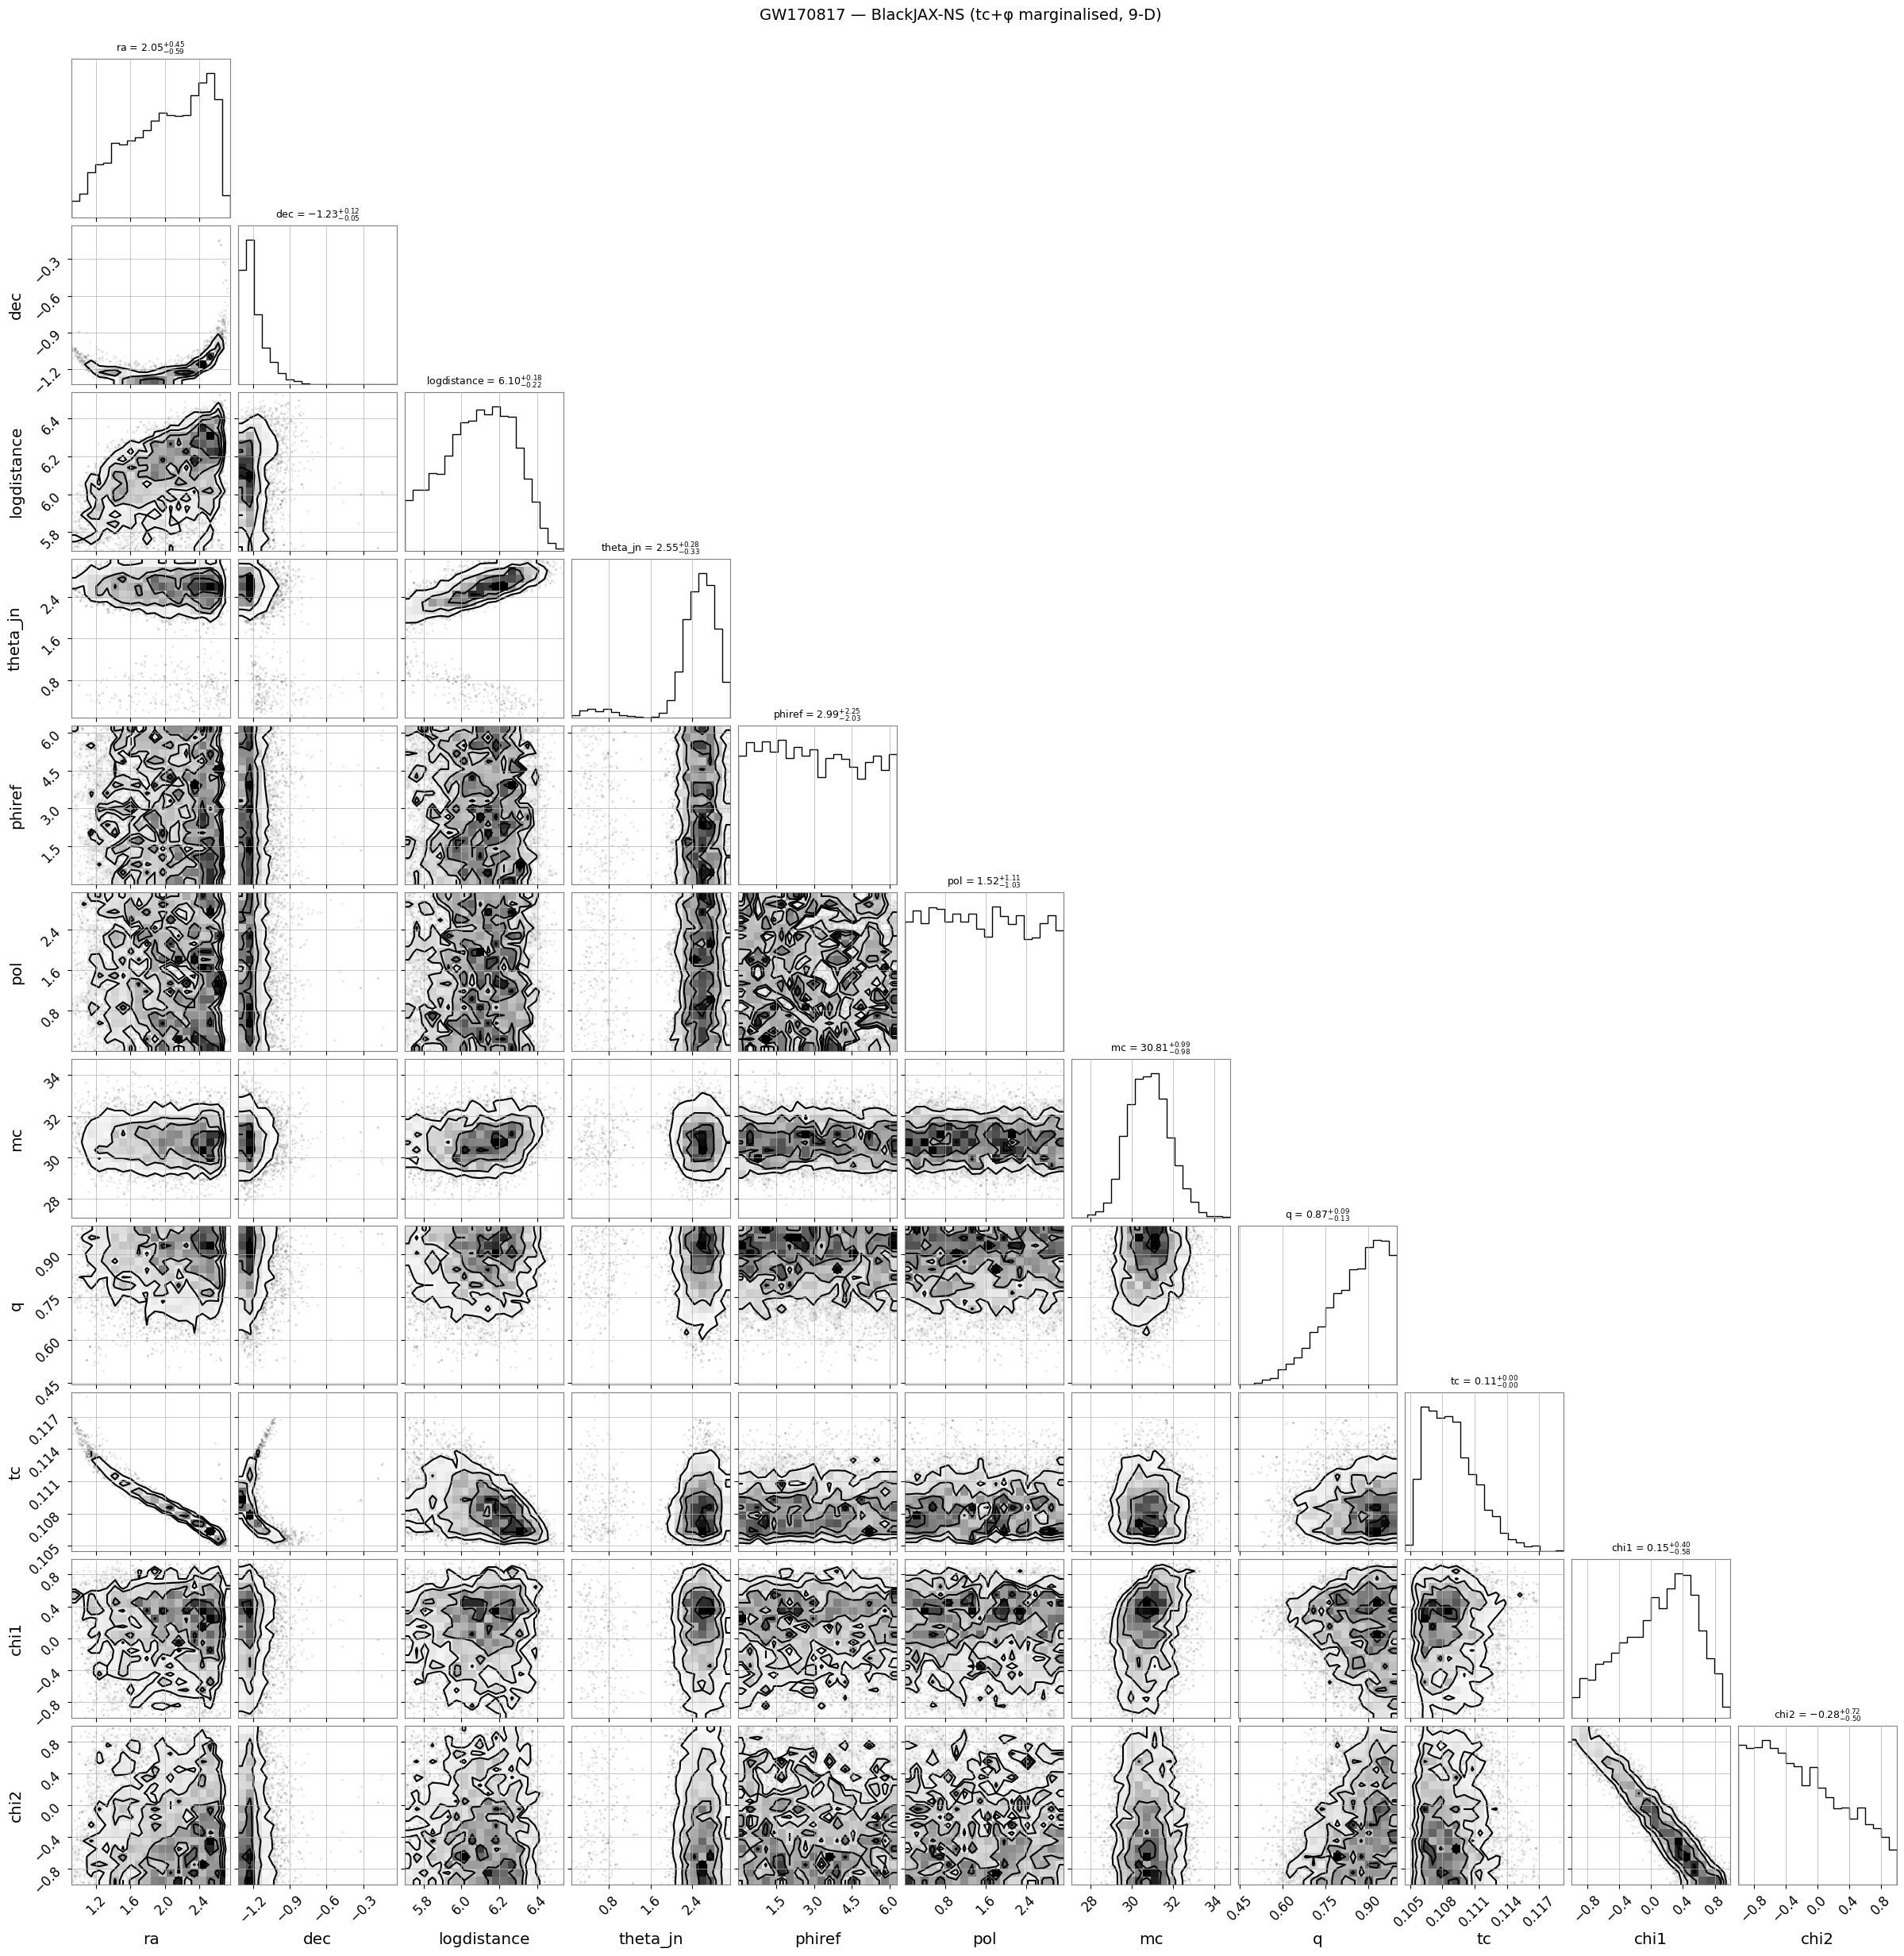

In [ ]:
import os
import pickle
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from corner import corner as corner_plot
from blackjax.ns.utils import finalise
from anesthetic import NestedSamples

# ── Define missing variables ───────────────────────────────────────────────
OUTDIR = "."  # Save in the current directory (change if needed)
LABEL = "run_4" # Define a label for your run
parameter_names = parameters_names # Fixing the typo to match previous cells

# ── Finalise: merge dead + live ──────────────────────────────────────────
final_state = finalise(state, dead)

# ── Save final state ─────────────────────────────────────────────────────
state_path = os.path.join(OUTDIR, f"{LABEL}_final_state.pkl")
with open(state_path, "wb") as f:
    pickle.dump(final_state, f)
print(f"Final state saved: {state_path}")

# ── Transform unit-cube → physical space ─────────────────────────────────
# Extract the actual parameter dict from the StateWithLogLikelihood namedtuple
unit_cube_positions = final_state.particles.position if hasattr(final_state.particles, 'position') else final_state.particles
physical_particles = transform_to_physical(unit_cube_positions, prior_transform_fn)

column_to_label = {
    "logdistance": r"$\ln d_L$", "theta_jn": r"$\theta_{JN}$", "pol": r"$\psi$",
    "mc": r"$\mathcal{M}_c$", "q": r"$q$", "chi1": r"$\chi_1$", "chi2": r"$\chi_2$",
    "lambda_1": r"$\Lambda_1$", "lambda_2": r"$\Lambda_2$",
}

# Extract log-likelihoods from the particles state
logL = final_state.particles.loglikelihood if hasattr(final_state.particles, 'loglikelihood') else final_state.loglikelihood
logL_birth_raw = final_state.particles.loglikelihood_birth if hasattr(final_state.particles, 'loglikelihood_birth') else final_state.loglikelihood_birth
logL_birth = jnp.where(jnp.isnan(logL_birth_raw), -jnp.inf, logL_birth_raw)

# ── Create and save NestedSamples ────────────────────────────────────────
samples_anesthetic = NestedSamples(
    physical_particles,
    logL=logL,
    logL_birth=logL_birth,
    labels=column_to_label,
    logzero=jnp.nan,
    dtype=jnp.float64,
)

csv_path = os.path.join(OUTDIR, f"{LABEL}_posterior.csv")
samples_anesthetic.to_csv(csv_path)
print(f"Posterior samples saved: {csv_path}")

# ── Plot Corner ──────────────────────────────────────────────────────────
# Generate equally-weighted samples
eq_samples = samples_anesthetic.sample(n=5000, replace=True)
eq_array = np.column_stack([np.array(eq_samples[k]) for k in _ravel_order])
ravel_to_param_idx = [_ravel_order.index(k) for k in parameter_names]
samples_plot = eq_array[:, ravel_to_param_idx]

fig = corner_plot(samples_plot, show_titles=True, labels=parameter_names, title_kwargs={"fontsize": 9})
fig.suptitle(f"GW170817 — BlackJAX-NS (tc+φ marginalised, 9-D)", fontsize=14, y=1.01)
corner_path = os.path.join(OUTDIR, f"{LABEL}_corner_final.png")
fig.savefig(corner_path, dpi=150, bbox_inches="tight")
print(f"Corner plot saved: {corner_path}")

## CORNER PLOTS

In [ ]:
from corner import corner

In [ ]:
ranges = [
    (0.5,  3   ),   # ra
    (-1.5, 0.4 ),   # dec
    (5,    6.6 ),   # logdistance
    (0,    3.14),   # theta_jn
    (0,    6.28),   # phiref
    (0,    3.14),   # pol
    (25,   35  ),   # mc
    (0.4,  1   ),   # q
    (0,    0.2 ),   # tc
    (-1,   1   ),   # chi1
    (-1,   1   ),   # chi2
]

In [ ]:
fig = corner(
    np.array(posterior_samples),
    show_titles  = True,
    smooth       = 1.,
    labels       = parameters_names,
    title_kwargs = {"fontsize": 12},
    range        = ranges,
)
fig.savefig(f"{folder}/{label}_corner.png")
plt.show()

## EVIDENCE PLOT (anesthetic)

Using [`anesthetic`](https://github.com/handley-lab/anesthetic) (also by Handley-lab) for a richer nested sampling analysis.

In [ ]:
try:
    from anesthetic import NestedSamples

    ns_samples = NestedSamples(
        data    = dead_points,
        logL    = log_Ls_dead,
        logL_birth = np.full(len(log_Ls_dead), -np.inf),
        columns = parameters_names,
    )

    fig_2d = ns_samples.plot_2d(parameters_names[:6])
    plt.suptitle("Anesthetic posterior (first 6 params)")
    fig_2d.savefig(f"{folder}/{label}_anesthetic.png")
    plt.show()
except Exception as e:
    print("Anesthetic plot skipped:", e)

In [ ]:
import pandas as pd
from google.colab import files

# Convert the posterior samples to a DataFrame with parameter names as columns
df_samples = pd.DataFrame(posterior_samples, columns=parameters_names)

# Save the DataFrame to a CSV file
csv_path = f"{folder}/posterior_samples.csv"
df_samples.to_csv(csv_path, index=False)
print(f"Samples successfully saved to {csv_path}")

# Trigger the download to your local machine
files.download(csv_path)


In [ ]:
dlogZ = logZ_live - logZ
print(f"Final dlogZ (logZ_live - logZ): {dlogZ:.4f}")
print(f"Fractional remaining evidence: {np.exp(dlogZ):.4f}")
print(f"Target convergence threshold: {np.log(convergence_dlogZ):.4f}")


# NEW PLOTS

# NEW CALCULATIONS

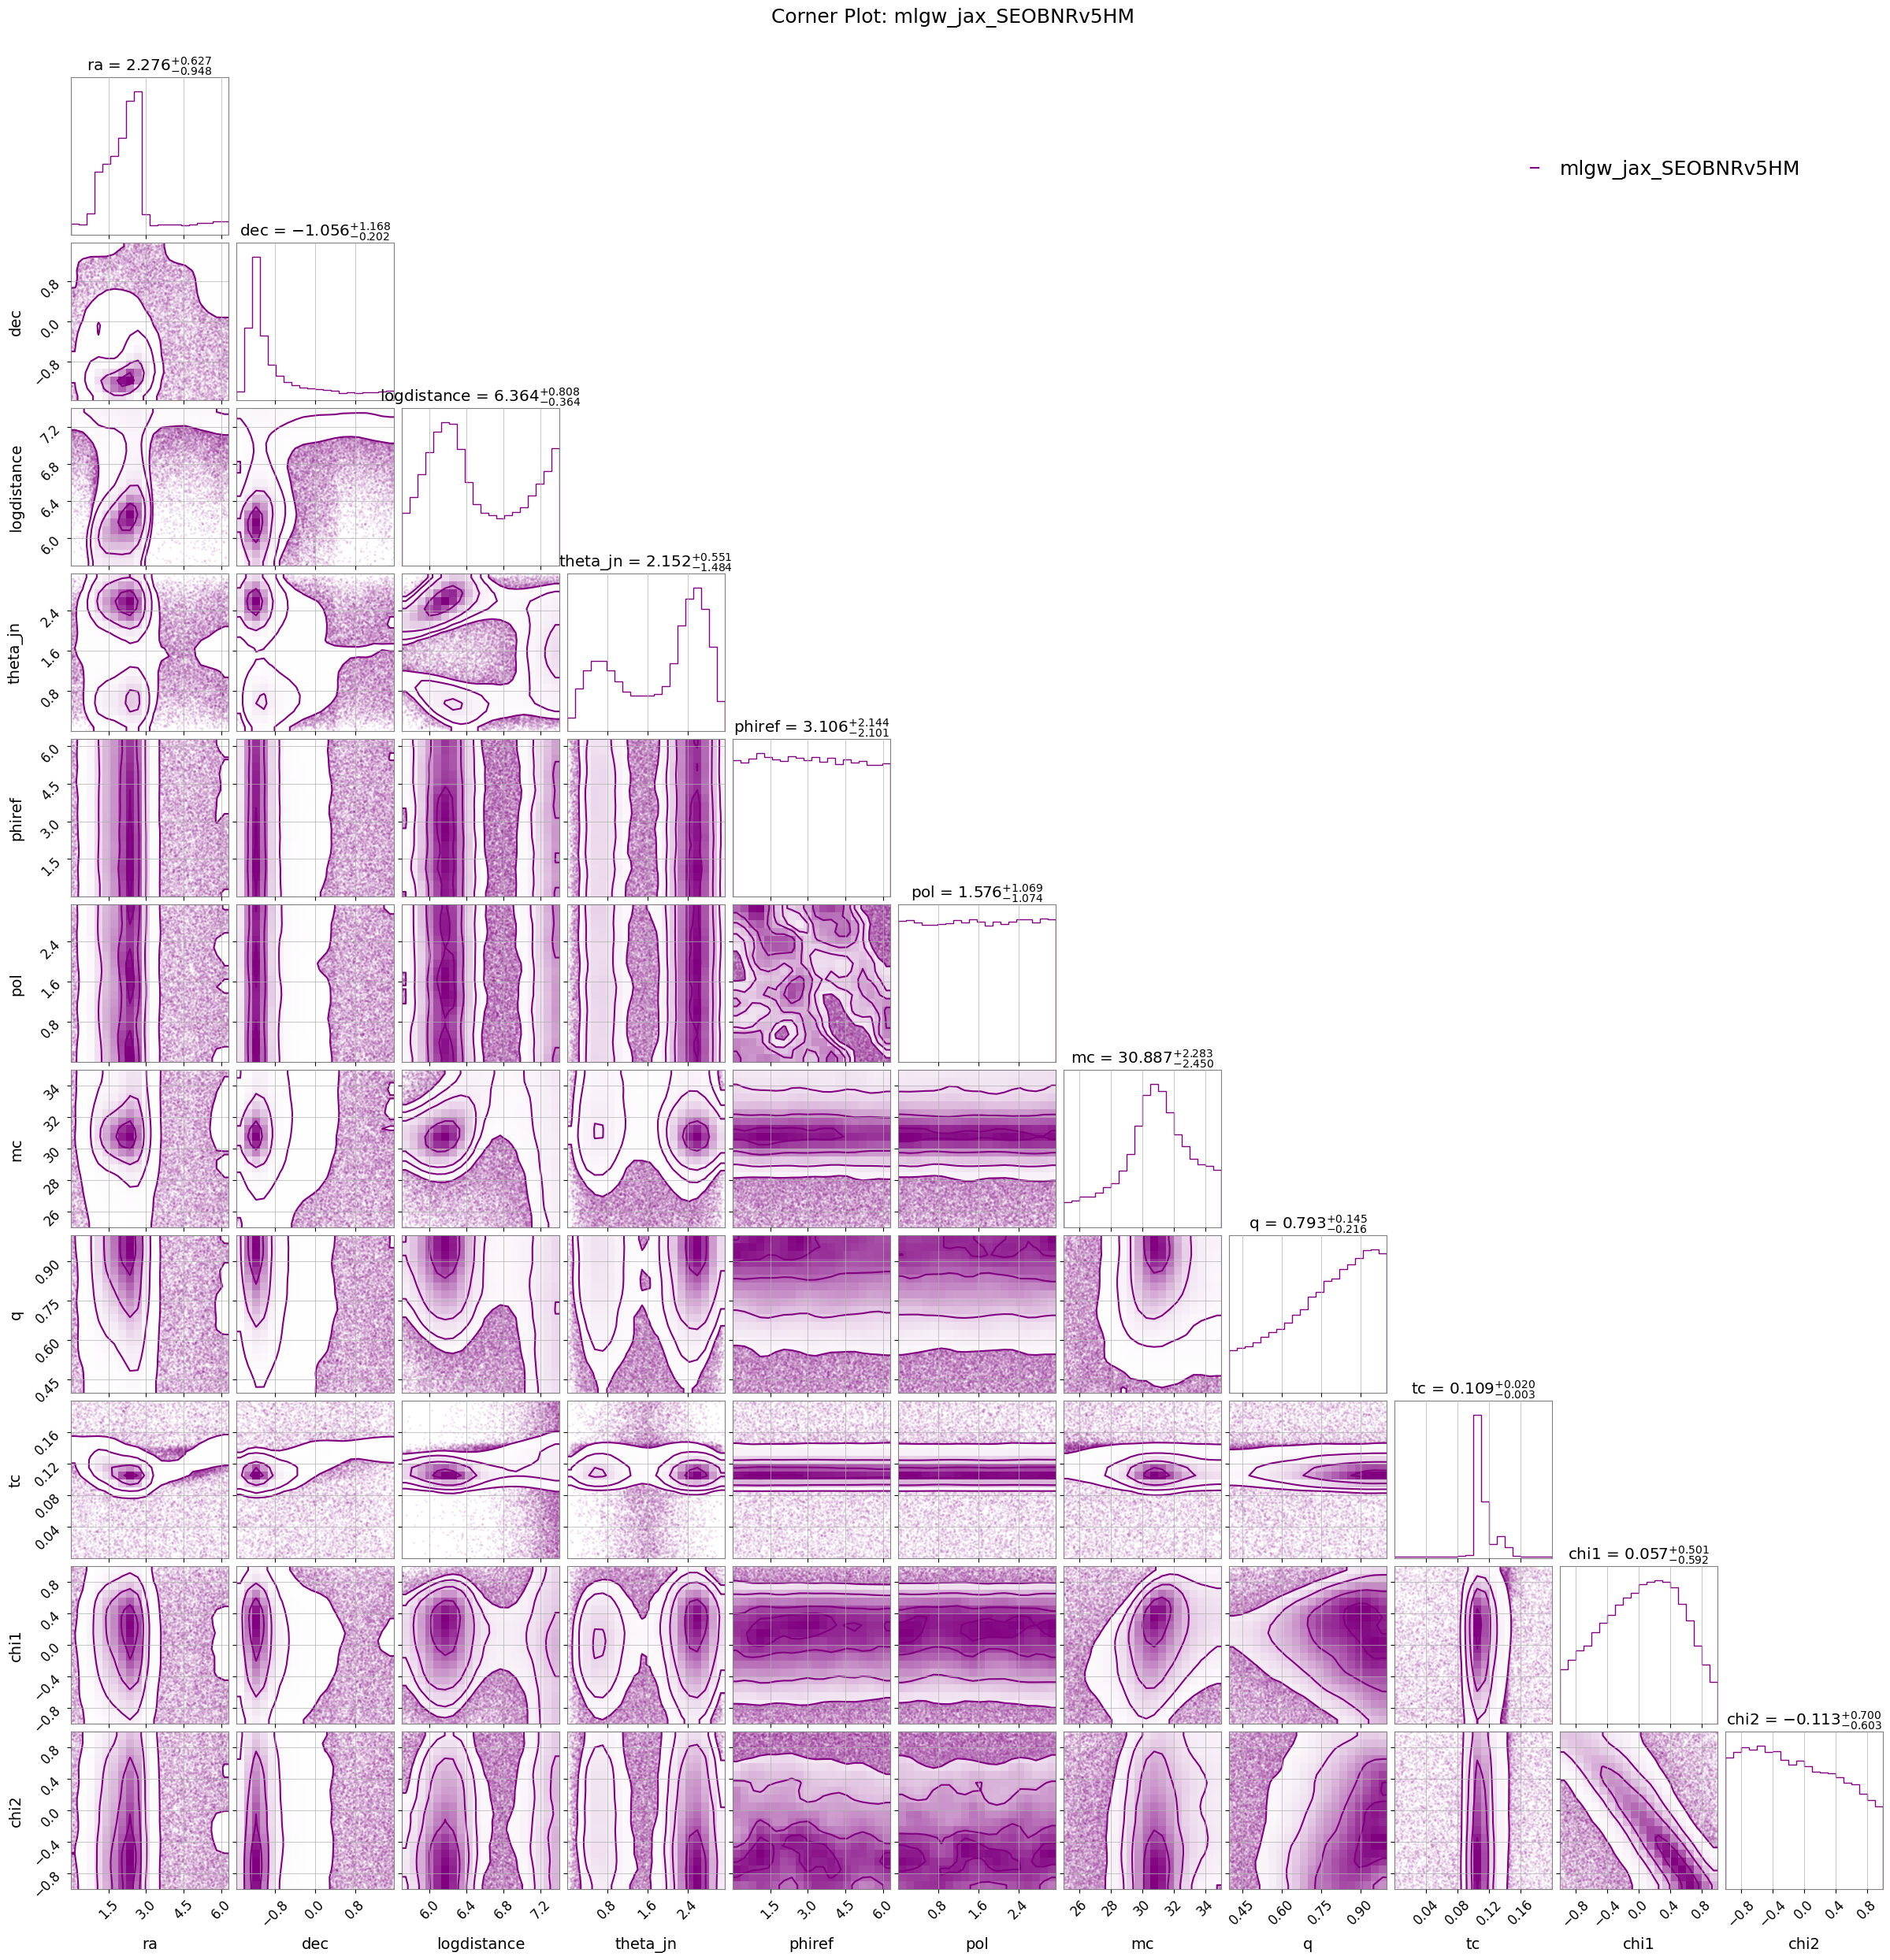

In [ ]:
!pip install corner
import pandas as pd
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Lê o CSV ignorando as linhas 1 e 2 que contêm os labels e os identificadores de weights do anesthetic
df_v5 = pd.read_csv("run_4_posterior.csv", skiprows=[1, 2])

# Explicitly set the preferred order of parameters
ordered_cols = ['ra', 'dec', 'logdistance', 'theta_jn', 'phiref', 'pol', 'mc', 'q', 'tc', 'chi1', 'chi2']
cols_to_plot = [col for col in ordered_cols if col in df_v5.columns]

# Extrai apenas os valores numéricos formatados corretamente
samples_v5 = df_v5[cols_to_plot].values.astype(float)

# Cria o plot de correlação (corner plot)
fig = corner.corner(
    samples_v5,
    labels=cols_to_plot,
    smooth=1,
    color='purple',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 14},
    show_titles=True,
    title_fmt='.3f',
    plot_contours=True
)

# Criação do item para a legenda
proxy_v5 = mlines.Line2D([], [], color='purple', label='mlgw_jax_SEOBNRv5HM')

# Adiciona a legenda na figura
fig.legend(handles=[proxy_v5], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=False)

plt.suptitle('Corner Plot: mlgw_jax_SEOBNRv5HM', fontsize=18, y=1.02)
plt.show()

In [ ]:
!pip install pesummary
import pandas as pd
import numpy as np
from pesummary.io import read

# Explicitly load the data to ensure 'samples' is defined
filename = 'IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5'
print("Loading data...")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 133.2 MB/s eta 0:00:00
Loading data...


In [ ]:
data = read(filename, disable_prior=True)




2026-05-22  09:47:31 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.
2026-05-22  09:47:31 PESummary WARNING : Unable to install 'pycbc'. You will not be able to use some of the inbuilt functions.
2026-05-22  09:47:36 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


In [ ]:
data

file: IGWN-GWTC2p1-v2-GW150914_095045_PEDataRelease_mixed_cosmo.h5
cls: pesummary.gw.file.formats.pesummary.PESummary
analyses: C01:IMRPhenomXPHM, C01:Mixed, C01:SEOBNRv4PHM

C01:IMRPhenomXPHM
-----------------
description: No description found
nsamples: 147634
parameters: chirp_mass, mass_ratio, ..., cos_tilt_1_infinity_only_prec_avg, cos_tilt_2_infinity_only_prec_avg

C01:Mixed
---------
description: No description found
nsamples: 3337
parameters: spin_2y, dec, ..., cos_tilt_1_infinity_only_prec_avg, cos_tilt_2_infinity_only_prec_avg

C01:SEOBNRv4PHM
---------------
description: No description found
nsamples: 1642
parameters: mass_1, mass_2, ..., viewing_angle, cos_iota

In [ ]:
samples = data.samples_dict['C01:Mixed']

In [ ]:
# Convert to a dictionary of numpy arrays, then to a DataFrame
samples_dict = {key: np.array(val) for key, val in samples.items()}
gwtc2p1_df = pd.DataFrame(samples_dict)

print(f"Extracted {len(gwtc2p1_df)} samples with {len(gwtc2p1_df.columns)} parameters.")
# Display the first few rows of the extracted samples
display(gwtc2p1_df.head())

Extracted 3337 samples with 59 parameters.


,spin_2y,dec,chirp_mass,redshift,theta_jn,ra,a_1,chi_p_2spin,viewing_angle,mass_1_source,...,psi,spin_1x,tilt_1_infinity_only_prec_avg,tilt_2_infinity_only_prec_avg,spin_1z_infinity_only_prec_avg,spin_2z_infinity_only_prec_avg,chi_eff_infinity_only_prec_avg,chi_p_infinity_only_prec_avg,cos_tilt_1_infinity_only_prec_avg,cos_tilt_2_infinity_only_prec_avg
0,0.015748,-1.202903,30.968395,0.096855,2.770786,1.283232,0.001510,0.014260,0.370807,37.734170,...,1.129086,0.000623,2.349193,0.595956,-0.001060,0.023234,0.009288,0.011208,-0.702138,0.827612
1,0.306186,-1.174466,31.697572,0.085872,2.587009,1.126872,0.927965,0.804829,0.554584,36.868923,...,2.207757,0.155915,1.155951,2.284016,0.374015,-0.383390,0.030806,0.849253,0.403048,-0.654272
2,-0.025789,-1.281479,29.433692,0.078809,2.463280,1.665790,0.436312,0.678088,0.678313,31.680987,...,1.587066,-0.364621,0.867368,2.584519,0.282222,-0.587906,-0.148147,0.357272,0.646836,-0.848806
3,-0.615255,-1.225446,28.342551,0.093687,2.786034,2.183548,0.534970,0.323450,0.355559,35.456986,...,2.816675,-0.275784,2.149757,1.715693,-0.292711,-0.102547,-0.213818,0.474605,-0.547154,-0.144390
4,-0.014314,-1.226182,30.856463,0.120825,2.832550,2.332550,0.118997,0.091785,0.309042,34.800813,...,1.517253,0.074419,2.170688,0.189723,-0.067180,0.058747,-0.010170,0.098219,-0.564553,0.982057


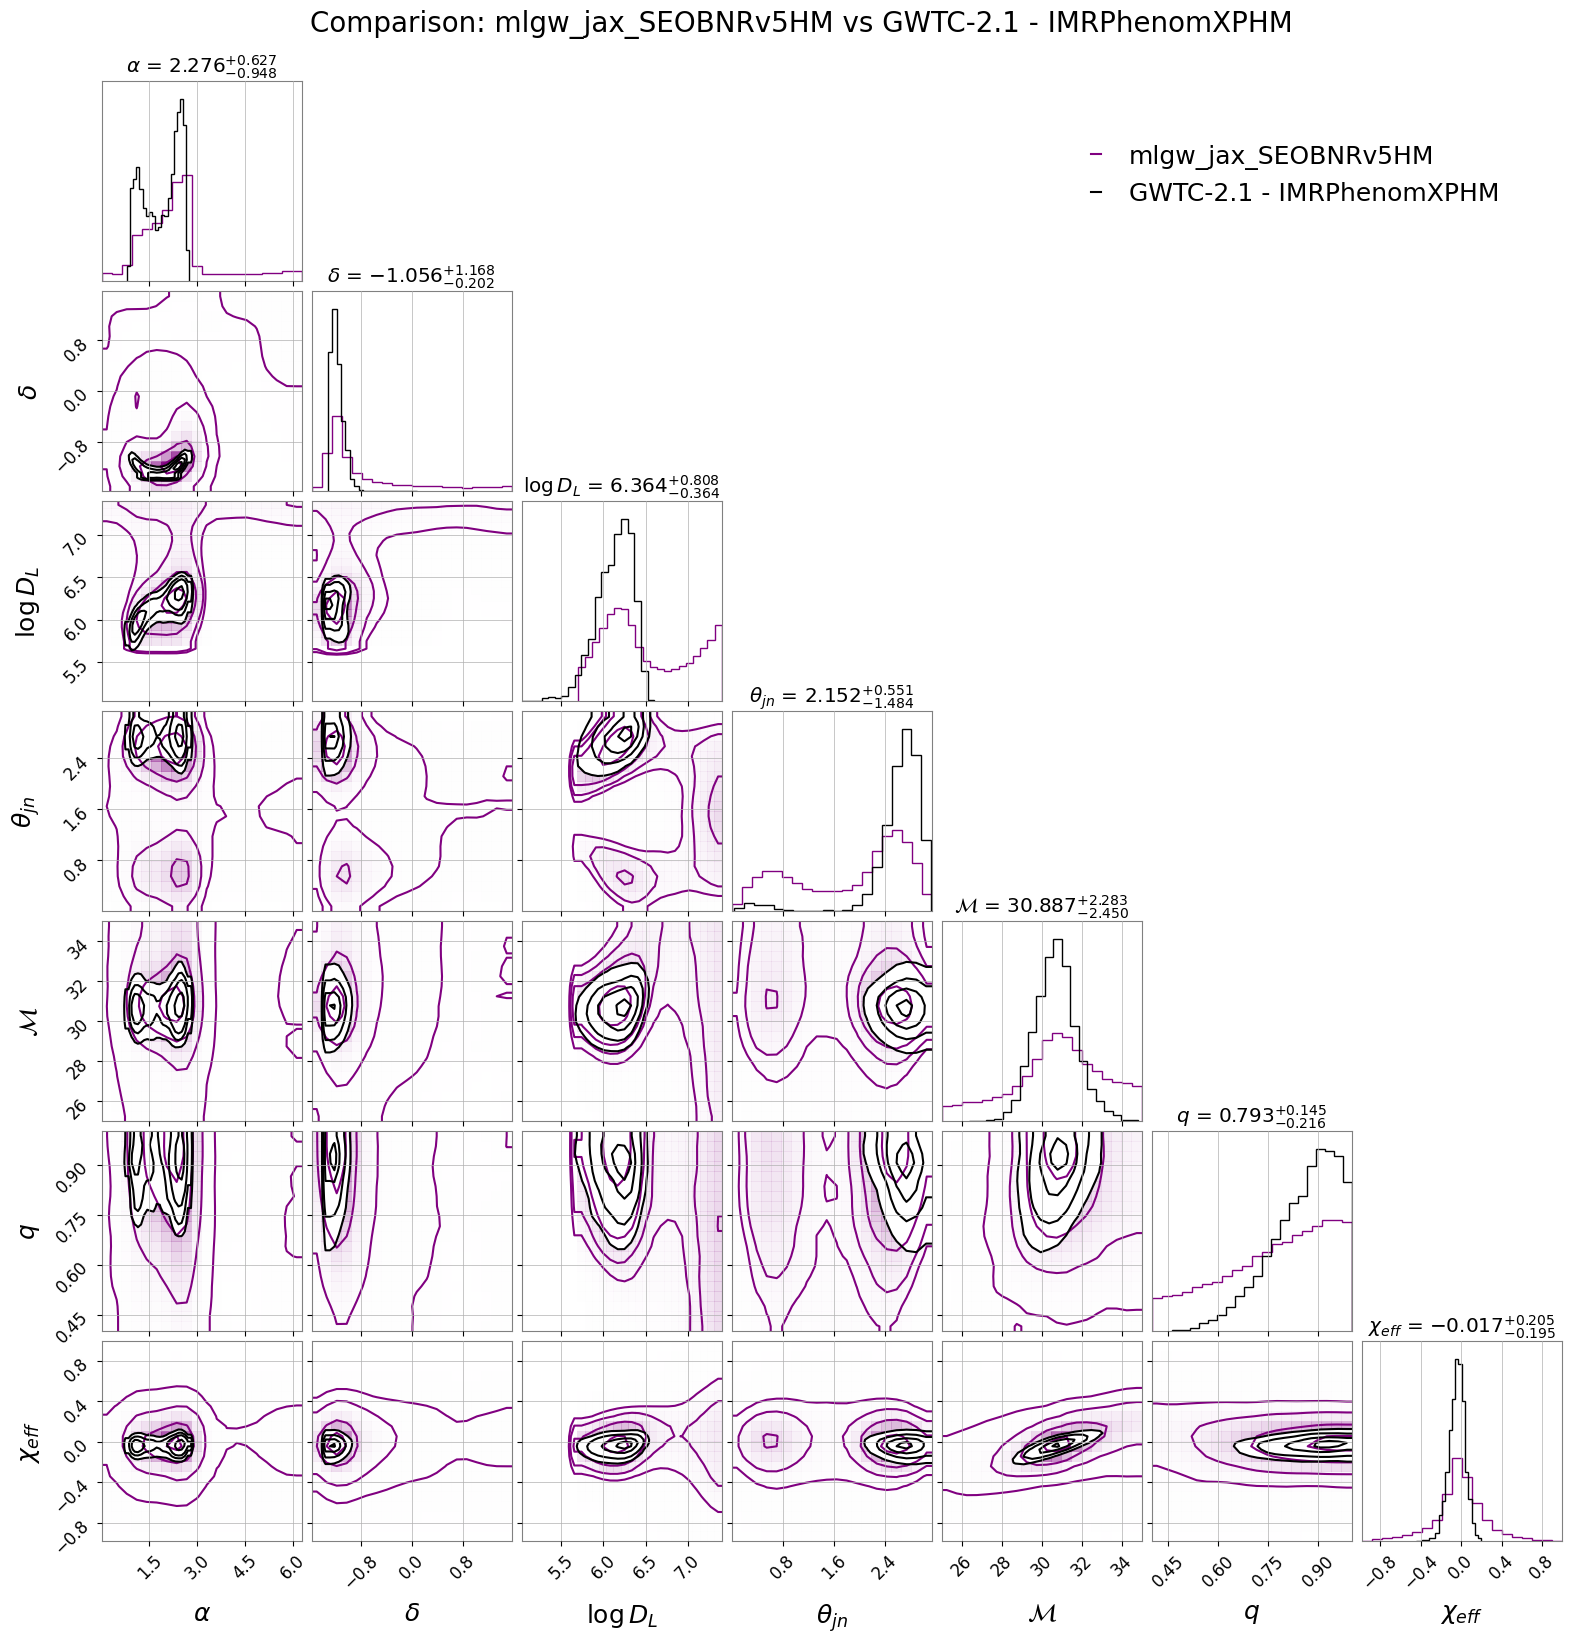

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# 1. Prepare GWOSC Data
# Extracting and converting relevant parameters
gwosc_mc = gwtc2p1_df['chirp_mass'].values
gwosc_q = gwtc2p1_df['mass_ratio'].values
gwosc_ra = np.mod(gwtc2p1_df['ra'].values, 2*np.pi)
gwosc_dec = gwtc2p1_df['dec'].values
gwosc_logdl = np.log(gwtc2p1_df['luminosity_distance'].values)  # Using log(DL)
gwosc_theta_jn = gwtc2p1_df['theta_jn'].values
gwosc_chi_eff = gwtc2p1_df['chi_eff'].values

gwosc_data = np.column_stack([gwosc_ra, gwosc_dec, gwosc_logdl, gwosc_theta_jn, gwosc_mc, gwosc_q, gwosc_chi_eff])

# 2. Prepare mlgw_jax_SEOBNRv5HM Data
# Using the df_v5 loaded previously
v5_mc = df_v5['mc'].values
v5_q = df_v5['q'].values
v5_ra = np.mod(df_v5['ra'].values, 2*np.pi)
v5_dec = df_v5['dec'].values
v5_logdl = df_v5['logdistance'].values  # Using logDL directly
v5_theta_jn = df_v5['theta_jn'].values

# Attempt to compute or extract chi_eff for v5 data
if 'chi_eff' in df_v5.columns:
    v5_chi_eff = df_v5['chi_eff'].values
else:
    # Try common spin column names
    chi1, chi2 = np.zeros_like(v5_mc), np.zeros_like(v5_mc)
    for c1, c2 in [('chi1', 'chi2'), ('chi_1', 'chi_2'), ('spin1z', 'spin2z'), ('a_1', 'a_2')]:
        if c1 in df_v5.columns and c2 in df_v5.columns:
            chi1, chi2 = df_v5[c1].values, df_v5[c2].values
            break

    factor = v5_mc * np.power(1. + v5_q, 1.0/5.0)
    m1 = factor * np.power(v5_q, -3.0/5.0)
    m2 = factor * np.power(v5_q, 2.0/5.0)
    v5_chi_eff = (m1 * chi1 + m2 * chi2) / (m1 + m2)

v5_data = np.column_stack([v5_ra, v5_dec, v5_logdl, v5_theta_jn, v5_mc, v5_q, v5_chi_eff])

# Parameter labels
labels = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'$\theta_{jn}$', r'$\mathcal{M}$', r'$q$', r'$\chi_{eff}$']

# 3. Create the corner plot
# Plot the SEOBNRv5HM data first (Base layer)
fig = corner.corner(
    v5_data,
    labels=labels,
    smooth=1,
    color='purple',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 18},
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# Overlay the GWOSC data
corner.corner(
    gwosc_data,
    fig=fig,
    smooth=0.9,
    color='black',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,
    plot_datapoints=False,
    plot_density=False
)

# 4. Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='purple', label='mlgw_jax_SEOBNRv5HM')
proxy_gwosc = mlines.Line2D([], [], color='black', label='GWTC-2.1 - IMRPhenomXPHM')

fig.legend(handles=[proxy_v5, proxy_gwosc], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=False)
plt.suptitle('Comparison: mlgw_jax_SEOBNRv5HM vs GWTC-2.1 - IMRPhenomXPHM', fontsize=20, y=1.02)
plt.show()


In [ ]:
v5_data.shape

(74000, 7)

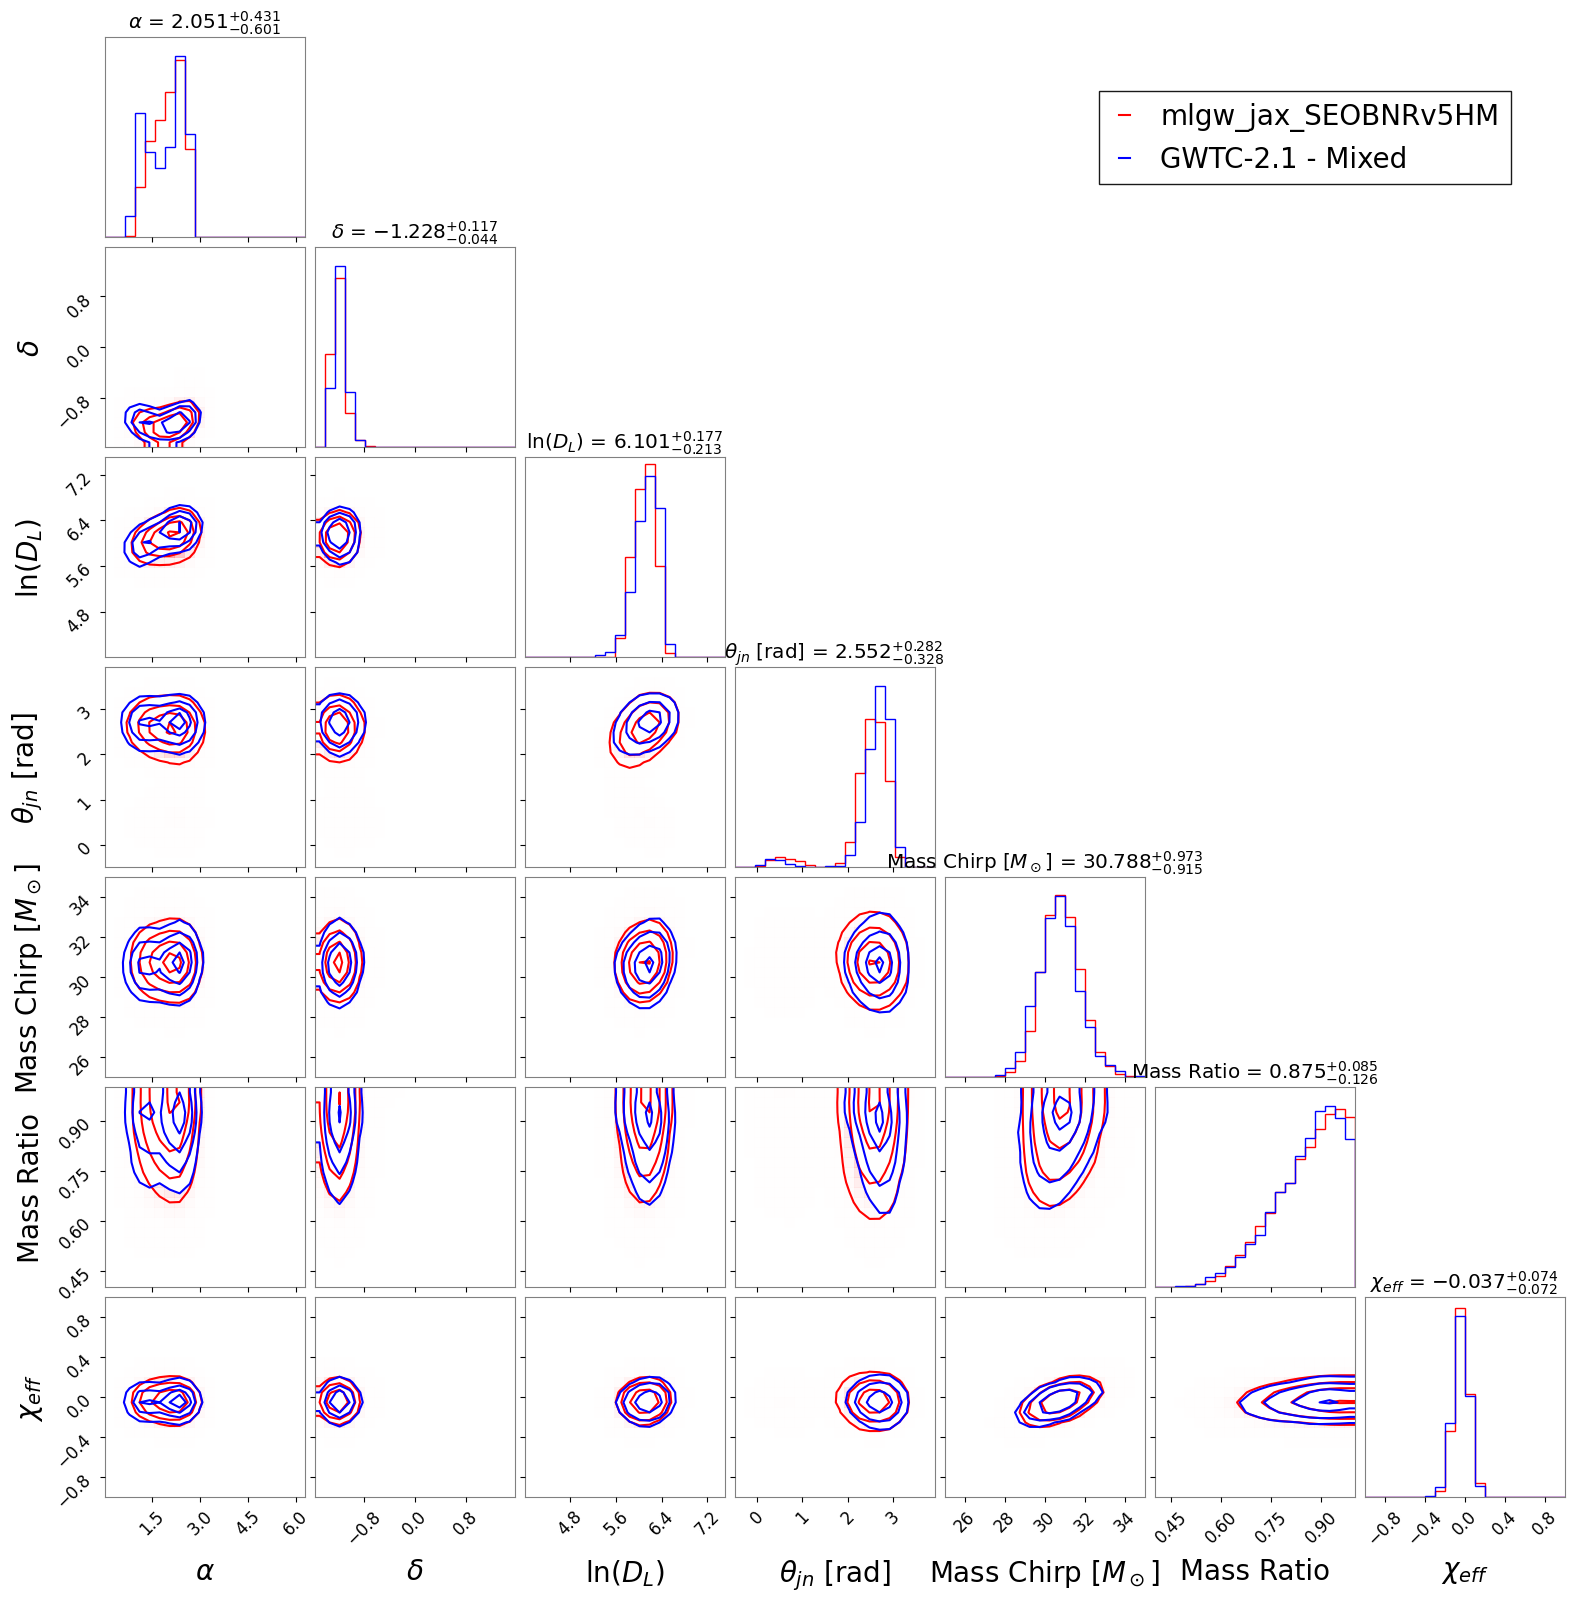

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

last_samples=20000

# 1. Extract C01:Mixed data from GWTC-2.1
samples_mixed = data.samples_dict['C01:Mixed']

# Extracting and converting relevant parameters
mixed_mc = np.array(samples_mixed['chirp_mass'])
mixed_q = np.array(samples_mixed['mass_ratio'])
mixed_ra = np.mod(np.array(samples_mixed['ra']), 2*np.pi)

# Handle declination/zenith correctly
if 'zenith' in samples_mixed.keys():
    mixed_dec = np.pi/2 - np.array(samples_mixed['zenith'])
else:
    mixed_dec = np.array(samples_mixed['dec'])

mixed_logdl = np.log(np.array(samples_mixed['luminosity_distance']))
mixed_theta_jn = np.array(samples_mixed['theta_jn'])
mixed_chi_eff = np.array(samples_mixed['chi_eff'])

# Stack the data
mixed_data = np.column_stack([mixed_ra, mixed_dec, mixed_logdl, mixed_theta_jn, mixed_mc, mixed_q, mixed_chi_eff])

# 2. Define labels and standardized ranges
labels_comp = [r'$\alpha$', r'$\delta$', r'$\ln(D_L)$', r'$\theta_{jn}$ [rad]', r'Mass Chirp [$M_\odot$]', r'Mass Ratio', r'$\chi_{eff}$']
ranges_comp = [
    (0, 2*np.pi),        # alpha (RA)
    (-np.pi/2, np.pi/2), # delta (Dec)
    (4.0, 7.5),          # logDL
    (-0.5, 1.25*np.pi),          # theta_jn
    (25.0, 35.0),        # Mc
    (0.4, 1.0),          # q
    (-1, 1)              # chi_eff
]

# 3. Create the Comparison Corner Plot
# MLGW-JAX SEOBNRv5HM (Purple) - Base layer
fig = corner.corner(
    v5_data[-last_samples:],
    labels=labels_comp,
    range=ranges_comp,
    smooth=1,
    color='red',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 20},
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# GWTC-2.1 Mixed (Green) - Overlay
corner.corner(
    mixed_data,
    fig=fig,
    range=ranges_comp,
    smooth=0.9,
    color='blue',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False,    # Turn off 2D density color filling
    label_kwargs={'fontsize': 22}
)

# 4. Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='red', label='mlgw_jax_SEOBNRv5HM')
proxy_mixed = mlines.Line2D([], [], color='blue', label='GWTC-2.1 - Mixed')

fig.legend(handles=[proxy_v5, proxy_mixed], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=20, frameon=True, edgecolor='black', facecolor='white', framealpha=0.9)

# Remove grid lines
for ax in fig.axes:
    ax.grid(False)

plt.savefig('corner_fig_dis_incl_included.png')
#plt.suptitle('Comparison: mlgw_jax_SEOBNRv5HM vs GWTC-2.1 Mixed', fontsize=20, y=1.02)
plt.show()

In [ ]:
import numpy as np

# Parameter names corresponding to the columns in gwosc_data and v5_data
param_names = ['ra', 'dec', 'logDL', 'theta_jn', 'Mc', 'q', 'chi_eff']

print(f"{'Parameter':<10} | {'Median GWTC-2.1':<15} | {'Median MLGW-JAX':<15} | {'Ratio (GWTC/MLGW)'}")
print("-" * 65)

for i, name in enumerate(param_names):
    med_gwosc = np.median(gwosc_data[:, i])
    med_mlgw = np.median(v5_data[:, i])

    # Calculate multiplying factor (handling division by zero just in case)
    factor = med_gwosc / med_mlgw if med_mlgw != 0 else np.nan

    print(f"{name:<10} | {med_gwosc:<15.4f} | {med_mlgw:<15.4f} | {factor:.4f}")


Parameter  | Median GWTC-2.1 | Median MLGW-JAX | Ratio (GWTC/MLGW)
-----------------------------------------------------------------
ra         | 2.0344          | 2.2757          | 0.8939
dec        | -1.1933         | -1.0557         | 1.1303
logDL      | 6.1598          | 6.3644          | 0.9678
theta_jn   | 2.6990          | 2.1522          | 1.2541
Mc         | 30.6872         | 30.8870         | 0.9935
q          | 0.8752          | 0.7927          | 1.1041
chi_eff    | -0.0383         | -0.0170         | 2.2561


In [ ]:
gwosc_data.shape

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# 1. Prepare GWOSC Data with standardizations
# Convert zenith to dec (dec = pi/2 - zenith) and wrap RA
gwosc_ra = np.mod(gwtc2p1_df['ra'].values, 2*np.pi)
if 'zenith' in gwtc2p1_df.columns:
    gwosc_dec = np.pi/2 - gwtc2p1_df['zenith'].values
else:
    gwosc_dec = gwtc2p1_df['dec'].values

gwosc_logdl = np.log(gwtc2p1_df['luminosity_distance'].values)
gwosc_theta_jn = gwtc2p1_df['theta_jn'].values
gwosc_mc = gwtc2p1_df['chirp_mass'].values
gwosc_q = gwtc2p1_df['mass_ratio'].values

gwosc_data = np.column_stack([gwosc_ra, gwosc_dec, gwosc_logdl, gwosc_theta_jn, gwosc_mc, gwosc_q])

# Parameter labels and common standardized ranges
labels = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'$\theta_{jn}$', r'$\mathcal{M}$', r'$q$']

# Updated ranges: RA [0, 2pi], Dec [-pi/2, pi/2], with sensible limits for others
combined_ranges = [
    (0, 2*np.pi),        # Right Ascension
    (-np.pi/2, np.pi/2), # Declination
    (5.0, 7.5),          # logDL
    (0, np.pi),          # theta_jn
    (25.0, 35.0),        # chirp mass
    (0.4, 1.0)           # mass ratio
]

# 3. Create the corner plot for GWOSC ONLY
fig = corner.corner(
    gwosc_data[20000:100000],
    labels=labels,
    range=combined_ranges,
    smooth=0.9,
    color='black',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 18},
    plot_contours=True,
    show_titles=True,
    title_fmt='.3f'
)

# 4. Add Legends and Title
proxy_gwosc = mlines.Line2D([], [], color='black', label='GWOSC samples')

fig.legend(handles=[proxy_gwosc], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=False)
plt.suptitle('GWOSC Samples (Standardized Angles)', fontsize=20, y=1.02)
plt.show()


### Corner Plot: Excluding Distance and Inclination

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Indices in v5_data and gwosc_data:
# 0: ra, 1: dec, 2: logDL, 3: theta_jn, 4: Mc, 5: q, 6: chi_eff
# We want to exclude 2 (logDL) and 3 (theta_jn)
indices_to_keep = [0, 1, 4, 5, 6]
labels_subset = [r'$\alpha$', r'$\delta$', r'$\mathcal{M}$', r'$q$', r'$\chi_{eff}$']

# Slice the data
v5_data_subset = v5_data[:, indices_to_keep]
gwosc_data_subset = gwosc_data[:, indices_to_keep]

# 1. Base layer: MLGW-JAX (Purple)
fig = corner.corner(
    v5_data_subset,
    labels=labels_subset,
    smooth=1,
    color='red',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 18},
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# 2. Overlay: GWOSC (Black)
corner.corner(
    gwosc_data_subset,
    fig=fig,
    smooth=0.9,
    color='blue',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,
    plot_datapoints=False,
    plot_density=False
)

# Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='red', label='mlgw_jax_SEOBNRv5HM')
proxy_gwosc = mlines.Line2D([], [], color='blue', label='GWTC-2.1 - IMRPhenomXPHM')

fig.legend(handles=[proxy_v5, proxy_gwosc], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=False)
plt.savefig('corner_fig.pdf')
#plt.suptitle('Comparison: mlgw_jax_SEOBNRv5HM vs GWTC-2.1 - IMRPhenomXPHM (Excluding logDL & theta_jn)', fontsize=20, y=1.02)
plt.show()


In [ ]:
import numpy as np
import corner
import matplotlib.pyplot as plt

# Load the dead points from the text file
file_path = "dead_points_blackjax_ns (7).txt"
print(f"Loading {file_path}...")
dead_points = np.loadtxt(file_path)

print(f"Loaded dead points with shape: {dead_points.shape}")

# Create the corner plot for the dead points
fig = corner.corner(
    dead_points[20000:],
    smooth=1,
    color='blue',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 14},
    show_titles=True,
    title_fmt='.3f',
    plot_contours=True
)

plt.suptitle('Corner Plot: Dead Points (BlackJAX Nested Sampling)', fontsize=18, y=1.02)
plt.show()


In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Remove the first 70% of the dead points
remove_idx = int(len(dead_points) * 0.7)
dp_sliced = dead_points[remove_idx:]

# 1. Extract and compute parameters from dead_points to match GWOSC
# Columns: 0:ra, 1:dec, 2:logDL, 3:theta_jn, 4:phi_ref, 5:psi, 6:Mc, 7:q, 8:tc, 9:chi1, 10:chi2
dp_Mc = dp_sliced[:, 6]
dp_q = dp_sliced[:, 7]
dp_chi1 = dp_sliced[:, 9]
dp_chi2 = dp_sliced[:, 10]

# Compute component masses and effective spin (chi_eff)
factor = dp_Mc * np.power(1. + dp_q, 1.0/5.0)
m1 = factor * np.power(dp_q, -3.0/5.0)
m2 = factor * np.power(dp_q, 2.0/5.0)
dp_chi_eff = (m1 * dp_chi1 + m2 * dp_chi2) / (m1 + m2)

dp_ra = np.mod(dp_sliced[:, 0], 2*np.pi)
dp_dec = dp_sliced[:, 1]
dp_logdl = dp_sliced[:, 2]
dp_theta_jn = dp_sliced[:, 3]

dp_data = np.column_stack([dp_ra, dp_dec, dp_logdl, dp_theta_jn, dp_Mc, dp_q, dp_chi_eff])

labels = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'$\theta_{jn}$', r'$\mathcal{M}$', r'$q$', r'$\chi_{eff}$']

# 2. Create the Comparison Corner Plot
# Dead Points (Blue) - Base layer
fig = corner.corner(
    dp_data,
    labels=labels,
    smooth=1,
    color='blue',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 18},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False,    # Turn off 2D density color filling
    show_titles=True,
    title_fmt='.3f'
)

# GWOSC (Black) - Overlay
corner.corner(
    gwosc_data,
    fig=fig,
    smooth=0.9,
    color='black',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False     # Turn off 2D density color filling
)

# 3. Add Legends and Title
proxy_dp = mlines.Line2D([], [], color='blue', label='Dead Points (BlackJAX NS)')
proxy_gwosc = mlines.Line2D([], [], color='black', label='GWTC-2.1 - IMRPhenomXPHM')

fig.legend(handles=[proxy_dp, proxy_gwosc], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=False)
plt.suptitle('Comparison: Dead Points vs GWTC-2.1', fontsize=20, y=1.02)
plt.show()


In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# 1. Prepare GWTC-1 Data from data_1 (pesummary object)
samples_dict_gwtc1 = data_1.samples_dict

gw1_ra = np.mod(samples_dict_gwtc1['ra'], 2*np.pi)
gw1_dec = np.array(samples_dict_gwtc1['dec'])
gw1_logdl = np.log(samples_dict_gwtc1['luminosity_distance'])
gw1_theta_jn = np.arccos(samples_dict_gwtc1['cos_theta_jn'])

# Ensure m1 >= m2 for GWTC-1
m1_in = np.array(samples_dict_gwtc1['mass_1'])
m2_in = np.array(samples_dict_gwtc1['mass_2'])
a1_in = np.array(samples_dict_gwtc1['a_1'])
a2_in = np.array(samples_dict_gwtc1['a_2'])
ct1_in = np.array(samples_dict_gwtc1['cos_tilt_1'])
ct2_in = np.array(samples_dict_gwtc1['cos_tilt_2'])

mask_swap = m2_in > m1_in

m1 = np.where(mask_swap, m2_in, m1_in)
m2 = np.where(mask_swap, m1_in, m2_in)
a1 = np.where(mask_swap, a2_in, a1_in)
a2 = np.where(mask_swap, a1_in, a2_in)
ct1 = np.where(mask_swap, ct2_in, ct1_in)
ct2 = np.where(mask_swap, ct1_in, ct2_in)

gw1_q = m2 / m1
gw1_mc = (m1 * m2)**(3/5) / (m1 + m2)**(1/5)

gw1_s1z = a1 * ct1
gw1_s2z = a2 * ct2

# Compute chi_eff for GWTC-1
gw1_chi_eff = (m1 * gw1_s1z + m2 * gw1_s2z) / (m1 + m2)

# Stack GWTC-1 data: [ra, dec, logDL, theta_jn, Mc, q, chi_eff]
gw1_data_v5_comp = np.column_stack([gw1_ra, gw1_dec, gw1_logdl, gw1_theta_jn, gw1_mc, gw1_q, gw1_chi_eff])

# 2. Define labels and standardized ranges
labels_v5 = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'$\theta_{jn}$', r'$\mathcal{M}$', r'$q$', r'$\chi_{eff}$']
ranges_v5 = [
    (0, 2*np.pi),        # alpha (RA)
    (-np.pi/2, np.pi/2), # delta (Dec)
    (5.0, 7.5),          # logDL
    (0, np.pi),          # theta_jn
    (25.0, 35.0),        # Mc
    (0.4, 1.0),          # q
    (-1, 1)              # chi_eff
]

# 3. Create the Comparison Corner Plot
# MLGW-JAX SEOBNRv5HM (Purple) - Base layer
fig = corner.corner(
    v5_data,
    labels=labels_v5,
    range=ranges_v5,
    smooth=1,
    color='purple',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 18},
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# GWTC-1 (Black) - Overlay
corner.corner(
    gw1_data_v5_comp,
    fig=fig,
    range=ranges_v5,
    smooth=0.9,
    color='black',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False     # Turn off 2D density color filling
)

# 4. Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='purple', label='mlgw_jax_SEOBNRv5HM')
proxy_gw1 = mlines.Line2D([], [], color='black', label='GWTC-1')

fig.legend(handles=[proxy_v5, proxy_gw1], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=False)
plt.suptitle('Comparison: mlgw_jax_SEOBNRv5HM vs GWTC-1', fontsize=20, y=1.02)
plt.show()


In [ ]:
print("Models available in GWTC-2.1 data release:")
if 'data' in locals():
    print(list(data.samples_dict.keys()))
else:
    print("GWTC-2.1 data not currently loaded in memory.")

print("\nModels available in GWTC-1 data release:")
if 'data_1' in locals():
    print(list(data_1.samples_dict.keys()))
else:
    print("GWTC-1 data not currently loaded in memory.")

In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

# 1. Extract SEOBNRv4PHM data from GWTC-2.1
samples_v4 = data.samples_dict['C01:SEOBNRv4PHM']

# Extracting and converting relevant parameters
v4_mc = np.array(samples_v4['chirp_mass'])
v4_q = np.array(samples_v4['mass_ratio'])
v4_ra = np.mod(np.array(samples_v4['ra']), 2*np.pi)

# Handle declination/zenith correctly
if 'zenith' in samples_v4.keys():
    v4_dec = np.pi/2 - np.array(samples_v4['zenith'])
else:
    v4_dec = np.array(samples_v4['dec'])

v4_logdl = np.log(np.array(samples_v4['luminosity_distance']))
v4_theta_jn = np.array(samples_v4['theta_jn'])
v4_chi_eff = np.array(samples_v4['chi_eff'])

# Stack the data
v4_data = np.column_stack([v4_ra, v4_dec, v4_logdl, v4_theta_jn, v4_mc, v4_q, v4_chi_eff])

# 2. Load and process mlgw_jax_SEOBNRv5HM data from posterior_samples (16).csv
df_v5_new = pd.read_csv("posterior_samples (16).csv")

v5_mc_new = df_v5_new['mc'].values
v5_q_new = df_v5_new['q'].values
v5_ra_new = np.mod(df_v5_new['ra'].values, 2*np.pi)
v5_dec_new = df_v5_new['dec'].values
v5_logdl_new = df_v5_new['logdistance'].values
v5_theta_jn_new = df_v5_new['theta_jn'].values

if 'chi_eff' in df_v5_new.columns:
    v5_chi_eff_new = df_v5_new['chi_eff'].values
else:
    chi1, chi2 = np.zeros_like(v5_mc_new), np.zeros_like(v5_mc_new)
    for c1, c2 in [('chi1', 'chi2'), ('chi_1', 'chi_2'), ('spin1z', 'spin2z'), ('a_1', 'a_2')]:
        if c1 in df_v5_new.columns and c2 in df_v5_new.columns:
            chi1, chi2 = df_v5_new[c1].values, df_v5_new[c2].values
            break
    factor = v5_mc_new * np.power(1. + v5_q_new, 1.0/5.0)
    m1 = factor * np.power(v5_q_new, -3.0/5.0)
    m2 = factor * np.power(v5_q_new, 2.0/5.0)
    v5_chi_eff_new = (m1 * chi1 + m2 * chi2) / (m1 + m2)

v5_data_new = np.column_stack([v5_ra_new, v5_dec_new, v5_logdl_new, v5_theta_jn_new, v5_mc_new, v5_q_new, v5_chi_eff_new])

# 3. Define labels and standardized ranges
labels_v4_comp = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'$\theta_{jn}$', r'$\mathcal{M}$', r'$q$', r'$\chi_{eff}$']
ranges_v4_comp = [
    (0, 2*np.pi),        # alpha (RA)
    (-np.pi/2, np.pi/2), # delta (Dec)
    (5.0, 7.5),          # logDL
    (0, np.pi),          # theta_jn
    (25.0, 35.0),        # Mc
    (0.4, 1.0),          # q
    (-1, 1)              # chi_eff
]

# 4. Create the Comparison Corner Plot
# MLGW-JAX SEOBNRv5HM (Purple) - Base layer
fig = corner.corner(
    v5_data_new,
    labels=labels_v4_comp,
    range=ranges_v4_comp,
    smooth=1,
    color='purple',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 18},
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# GWTC-2.1 SEOBNRv4PHM (Orange) - Overlay
corner.corner(
    v4_data,
    fig=fig,
    range=ranges_v4_comp,
    smooth=0.9,
    color='orange',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False     # Turn off 2D density color filling
)

# 5. Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='purple', label='mlgw_jax_SEOBNRv5HM')
proxy_v4 = mlines.Line2D([], [], color='orange', label='GWTC-2.1 - SEOBNRv4PHM')

fig.legend(handles=[proxy_v5, proxy_v4], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=False)
plt.suptitle('Comparison: mlgw_jax_SEOBNRv5HM vs GWTC-2.1 SEOBNRv4PHM', fontsize=20, y=1.02)
plt.show()


In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# Recreate gwosc_data to ensure it has 7 dimensions (including chi_eff)
gwosc_ra = np.mod(gwtc2p1_df['ra'].values, 2*np.pi)
if 'zenith' in gwtc2p1_df.columns:
    gwosc_dec = np.pi/2 - gwtc2p1_df['zenith'].values
else:
    gwosc_dec = gwtc2p1_df['dec'].values

gwosc_logdl = np.log(gwtc2p1_df['luminosity_distance'].values)
gwosc_theta_jn = gwtc2p1_df['theta_jn'].values
gwosc_mc = gwtc2p1_df['chirp_mass'].values
gwosc_q = gwtc2p1_df['mass_ratio'].values
gwosc_chi_eff = gwtc2p1_df['chi_eff'].values

gwosc_data = np.column_stack([gwosc_ra, gwosc_dec, gwosc_logdl, gwosc_theta_jn, gwosc_mc, gwosc_q, gwosc_chi_eff])

# Define labels and standardized ranges
labels_comp = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'$\theta_{jn}$', r'$\mathcal{M}$', r'$q$', r'$\chi_{eff}$']
ranges_comp = [
    (0, 2*np.pi),        # alpha (RA)
    (-np.pi/2, np.pi/2), # delta (Dec)
    (5.0, 7.5),          # logDL
    (0, np.pi),          # theta_jn
    (25.0, 35.0),        # Mc
    (0.4, 1.0),          # q
    (-1, 1)              # chi_eff
]

# Create the Comparison Corner Plot
# MLGW-JAX SEOBNRv5HM (Purple) - Base layer
fig = corner.corner(
    v5_data,
    labels=labels_comp,
    range=ranges_comp,
    smooth=1,
    color='purple',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 14}, # Decreased font size
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# GWTC-2.1 IMRPhenomXPHM (Black) - Overlay
corner.corner(
    gwosc_data,
    fig=fig,
    range=ranges_comp,
    smooth=0.9,
    color='black',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False     # Turn off 2D density color filling
)

# Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='purple', label='mlgw_jax_SEOBNRv5HM')
proxy_gwosc = mlines.Line2D([], [], color='black', label='GWTC-2.1 - IMRPhenomXPHM')

# Placed legend in a box
fig.legend(handles=[proxy_v5, proxy_gwosc], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=True, edgecolor='black', facecolor='white', framealpha=0.9)
plt.suptitle('Comparison: mlgw_jax_SEOBNRv5HM vs GWTC-2.1 IMRPhenomXPHM', fontsize=20, y=1.02)
plt.show()


In [ ]:
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np

# 1. Extract C01:Mixed data from GWTC-2.1
samples_mixed = data.samples_dict['C01:Mixed']

# Extracting and converting relevant parameters
mixed_mc = np.array(samples_mixed['chirp_mass'])
mixed_q = np.array(samples_mixed['mass_ratio'])
mixed_ra = np.mod(np.array(samples_mixed['ra']), 2*np.pi)

# Handle declination/zenith correctly
if 'zenith' in samples_mixed.keys():
    mixed_dec = np.pi/2 - np.array(samples_mixed['zenith'])
else:
    mixed_dec = np.array(samples_mixed['dec'])

mixed_logdl = np.log(np.array(samples_mixed['luminosity_distance']))
mixed_theta_jn = np.array(samples_mixed['theta_jn'])
mixed_chi_eff = np.array(samples_mixed['chi_eff'])

# Stack the data
mixed_data = np.column_stack([mixed_ra, mixed_dec, mixed_logdl, mixed_theta_jn, mixed_mc, mixed_q, mixed_chi_eff])

# 2. Define labels and standardized ranges
labels_comp = [r'$\alpha$', r'$\delta$', r'$\log{D_{L}}$', r'$\theta_{jn}$', r'$\mathcal{M}$', r'$q$', r'$\chi_{eff}$']
ranges_comp = [
    (0, 2*np.pi),        # alpha (RA)
    (-np.pi/2, np.pi/2), # delta (Dec)
    (5.0, 7.5),          # logDL
    (0, np.pi),          # theta_jn
    (25.0, 35.0),        # Mc
    (0.4, 1.0),          # q
    (-1, 1)              # chi_eff
]

# 3. Create the Comparison Corner Plot
# MLGW-JAX SEOBNRv5HM (Purple) - Base layer
fig = corner.corner(
    v5_data,
    labels=labels_comp,
    range=ranges_comp,
    smooth=1,
    color='red',
    hist_kwargs={'density': True},
    label_kwargs={'fontsize': 14}, # Decreased font size
    plot_contours=True,
    show_titles=True,
    plot_datapoints=False,
    title_fmt='.3f'
)

# GWTC-2.1 Mixed (Green) - Overlay
corner.corner(
    mixed_data,
    fig=fig,
    range=ranges_comp,
    smooth=0.9,
    color='blue',
    hist_kwargs={'density': True},
    plot_contours=True,
    fill_contours=False,   # Do not fill contours
    plot_datapoints=False, # Do not plot datapoints
    plot_density=False     # Turn off 2D density color filling
)

# 4. Add Legends and Title
proxy_v5 = mlines.Line2D([], [], color='red', label='mlgw_jax_SEOBNRv5HM')
proxy_mixed = mlines.Line2D([], [], color='blue', label='GWTC-2.1 - Mixed')

# Placed legend in a box
fig.legend(handles=[proxy_v5, proxy_mixed], loc='upper right', bbox_to_anchor=(0.95, 0.95), fontsize=18, frameon=True, edgecolor='black', facecolor='white', framealpha=0.9)

# Remove grid lines
for ax in fig.axes:
    ax.grid(False)

plt.savefig('corner_fig_dis_incl_included.png')
#plt.suptitle('Comparison: mlgw_jax_SEOBNRv5HM vs GWTC-2.1 Mixed', fontsize=20, y=1.02)
plt.show()


In [ ]:
import shutil
import os
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the destination directory
dest_dir = '/content/drive/MyDrive/'

# Save the data arrays to local disk first
np.save('v5_data_new.npy', v5_data_new)
np.save('mixed_data.npy', mixed_data)

# Files to copy to Drive
files_to_copy = [
    'corner_fig_dis_incl_included.pdf',
    'v5_data_new.npy',
    'mixed_data.npy'
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, dest_dir)
        print(f"Successfully copied {file} to {dest_dir}")
    else:
        print(f"File {file} not found in the current directory.")

In [ ]:
import numpy as np
import corner
import matplotlib.pyplot as plt

# 1. Print current dlogZ
logZ_acc = float(state.integrator.logZ)
logZ_live = float(state.integrator.logZ_live)
dlogZ = logZ_live - logZ_acc

print(f"Current logZ (accumulated): {logZ_acc:.4f}")
print(f"Current logZ_live: {logZ_live:.4f}")
print(f"Current dlogZ (logZ_live - logZ_acc): {dlogZ:.4f}")

# 2. Plot corner plot of dead points so far
if len(dead_points) > 0:
    dp = np.array(dead_points)
    ll_dead = np.array(log_Ls_dead)
    n_dead = len(dp)

    # Calculate weights for the dead points
    i_arr = np.arange(1, n_dead + 1)
    log_X_i = -i_arr / n_live
    log_delta_X = log_X_i + np.log1p(-np.exp(-1.0 / n_live))
    log_w = ll_dead + log_delta_X

    log_w_norm = log_w - np.logaddexp.reduce(log_w)
    weights = np.exp(log_w_norm)
    weights /= weights.sum()

    # Resample
    n_samples = min(n_dead, 10000)
    idx = np.random.choice(n_dead, size=n_samples, replace=True, p=weights)
    samples_so_far = dp[idx]

    # Optionally restrict to the main parameters for a cleaner mid-run plot
    # Or plot all of them if desired.
    fig = corner.corner(
        samples_so_far,
        labels=parameters_names,
        show_titles=True,
        smooth=1.0,
        title_kwargs={"fontsize": 10}
    )
    plt.suptitle("Posterior Samples (from dead points so far)", fontsize=16, y=1.02)
    plt.show()
else:
    print("Not enough dead points collected yet to plot a corner plot.")